# Final Modeling Notebook — Structural Credibility Classification

This notebook contains the cleaned final modeling workflow for the thesis. It keeps only the final pipeline and removes intermediate/older experimental cells.

**Task:** binary classification of high-credibility (`0`) versus medium-credibility (`1`) news sources.  
**Positive/minority class:** medium credibility (`1`).  
**Main evaluation design:** nested stratified cross-validation with inner-loop hyperparameter tuning and threshold selection.

## Notebook structure
1. Imports and global settings
2. Load final feature table
3. Define target and feature families
4. Data checks and class balance
5. Tuning and evaluation helpers
6. Final nested model comparison
7. Feature-family ablation analysis
8. Precision-recall curves
9. Confusion matrix for the final model
10. Subgroup error analysis

In [3]:
# Optional setup: uncomment if packages are missing in your environment.
# %pip install pandas numpy matplotlib scikit-learn imbalanced-learn xgboost openpyxl
# %pip install tabpfn

In [2]:
%pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## 1. Imports and global settings

All random states are fixed to improve reproducibility. TabPFN is optional because it may require additional installation and can be computationally expensive.

In [2]:
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_curve,
)
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

import os
os.environ["TABPFN_ALLOW_CPU_LARGE_DATASET"] = "1"
# Optional TabPFN import
try:
    from tabpfn import TabPFNClassifier
    TABPFN_AVAILABLE = True
except Exception as e:
    TabPFNClassifier = None
    TABPFN_AVAILABLE = False
    print("TabPFN is not available. TabPFN sections will be skipped unless installed.")
    print("Import error:", e)

In [3]:
# ============================================================
# GLOBAL SETTINGS
# ============================================================

RANDOM_STATE = 42
OUTER_SPLITS = 5
INNER_SPLITS = 5

# Randomized-search iterations used in the final thesis workflow
N_ITER_RF = 60
N_ITER_XGB = 80
N_ITER_SMOTE_XGB = 80

# Threshold grids
TREE_THRESHOLDS = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
TABPFN_THRESHOLDS = np.round(np.arange(0.10, 0.91, 0.01), 2).tolist()

# Set to True when you want to run TabPFN inside the final comparison.
# Keep False when checking the notebook quickly, because TabPFN can be slow.
RUN_TABPFN = False
TABPFN_N_ESTIMATORS = 4

OUTPUT_DIR = Path("modeling_outputs_clean")
OUTPUT_DIR.mkdir(exist_ok=True)

## 2. Load final feature table

The notebook expects the merged final feature table with 3,044 sources and the engineered structural features. Adjust `DATA_PATH` only if the file is stored under another name or location.

In [4]:
DATA_PATH = Path("scs_feature_table_final_3044.csv")
TARGET_COL = "target"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Place the final feature table in the same folder as this notebook "
        "or update DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)
print("Data shape:", df.shape)
display(df.head())

Data shape: (3044, 42)


,url,mbfc-credibility-rating,target,html_filename,css_filename,dom_max_depth,dom_avg_branching,dom_branching_std,json_ld_present,social_link_ratio,semantic_tag_ratio,nav_max_list_depth,text_to_tag_ratio,interactive_ratio,external_link_ratio,internal_to_external_link_ratio,nav_link_ratio,empty_link_ratio,heading_density,paragraph_density,meta_description_present,css_class_token_entropy,css_reuse_factor,inline_style_density,country,media-type,iframe_ratio,adtech_script_ratio,explicit_ad_slot_count,header_bidding_present,script_tag_ratio,third_party_script_ratio,ad_keyword_present,css_selector_count,boilerplate_selector_share,icon_selector_share,custom_dominant_prefix_share,custom_prefix_family_count,custom_bem_share,media_query_density,html_css_class_coverage,unused_css_class_ratio
0,http://auburnpub.com/,high credibility,0,auburnpub.com.html,auburnpub.com.css,24,1.580937,3.276441,1,0.000000,0.033766,2,5.252987,0.132987,0.056911,2.772589,0.069106,0.020325,0.032208,0.018701,1,6.839468,5.462302,0.011948,usa,newspaper,0.001039,0.018868,14,1,0.027532,0.377358,1,2232,0.496957,0.006085,0.080645,81,0.000000,0.054531,0.15415,0.841785
1,http://autisticadvocacy.org/,high credibility,0,autisticadvocacy.org.html,autisticadvocacy.org.css,25,1.695876,3.555944,1,0.044118,0.018219,2,3.292510,0.139676,0.080882,2.435074,0.382353,0.154412,0.020243,0.003036,1,5.868526,4.013263,0.013158,usa,organization/foundation,0.000000,0.000000,0,0,0.082996,0.231707,0,94,0.027778,0.000000,0.571429,10,0.000000,0.042553,0.00000,1.000000
2,http://bgr.com/,high credibility,0,bgr.com.html,bgr.com.css,15,1.778881,2.072837,1,0.031496,0.033469,2,6.728195,0.197262,0.076115,2.546838,0.139108,0.175853,0.036004,0.024848,1,7.248820,6.898305,0.013185,usa,website,0.000507,0.000000,16,0,0.037525,0.175676,1,210,0.179245,0.000000,0.839080,15,0.000000,0.000000,0.00000,1.000000
3,http://bnonews.com/,high credibility,0,bnonews.com.html,bnonews.com.css,26,1.957377,2.460728,1,0.129032,0.010033,2,8.167224,0.155518,0.139785,1.914820,0.634409,0.172043,0.023411,0.061873,1,5.347626,6.085938,0.000000,netherlands,news agency,0.000000,0.000000,0,0,0.048495,0.068966,1,1309,0.842667,0.000000,0.203390,29,0.016949,0.025404,0.00000,1.000000
4,http://c4ads.org/,high credibility,0,c4ads.org.html,c4ads.org.css,20,7.603524,6.757604,1,0.030928,0.011584,0,1.493484,0.031856,0.113402,2.100061,0.030928,0.010309,0.011874,0.001158,1,6.268268,3.626374,0.001158,usa,organization/foundation,0.000290,0.000000,0,0,0.004054,0.142857,1,0,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.00000,0.000000


## 3. Define feature families and target

The feature families correspond to the methodology section: DOM hierarchy, CSS regularity, and ad-density features. The target is encoded as `0 = high credibility` and `1 = medium credibility`.

In [5]:
# DOM hierarchy features
dom_cols = [
    "dom_max_depth",
    "dom_avg_branching",
    "dom_branching_std",
    "social_link_ratio",
    "semantic_tag_ratio",
    "nav_max_list_depth",
    "text_to_tag_ratio",
    "interactive_ratio",
    "external_link_ratio",
    "internal_to_external_link_ratio",
    "nav_link_ratio",
    "empty_link_ratio",
    "heading_density",
    "paragraph_density",
    "meta_description_present",
]

# CSS regularity features
css_feature_cols = [
    "css_class_token_entropy",
    "css_reuse_factor",
    "inline_style_density",
    "css_selector_count",
    "icon_selector_share",
    "custom_bem_share",
    "media_query_density",
    "unused_css_class_ratio",
]

# Ad-density features
ad_cols = [
    "iframe_ratio",
    "adtech_script_ratio",
    "explicit_ad_slot_count",
    "header_bidding_present",
    "script_tag_ratio",
    "third_party_script_ratio",
    "ad_keyword_present",
]

feature_cols = dom_cols + css_feature_cols + ad_cols

missing_features = [c for c in feature_cols if c not in df.columns]
if missing_features:
    raise ValueError(f"Missing expected feature columns: {missing_features}")
if TARGET_COL not in df.columns:
    raise ValueError(f"Missing target column: {TARGET_COL}")

X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
y = df[TARGET_COL].astype(int)

if X.isna().sum().sum() > 0:
    missing_summary = X.isna().sum()[X.isna().sum() > 0]
    raise ValueError(f"X contains missing values. Handle these before modeling:\n{missing_summary}")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Total features:", len(feature_cols))
print("0 = high credibility; 1 = medium credibility")

X shape: (3044, 30)
y shape: (3044,)
Total features: 30
0 = high credibility; 1 = medium credibility


## 4. Data checks and class balance

This section gives a compact audit of the final modeling dataset before fitting models.

In [6]:
class_balance = (
    y.value_counts()
    .sort_index()
    .rename(index={0: "High credibility (0)", 1: "Medium credibility (1)"})
    .to_frame("n")
)
class_balance["share"] = class_balance["n"] / class_balance["n"].sum()
class_balance["share_pct"] = (100 * class_balance["share"]).round(2)

display(class_balance)

scale_pos_weight_full = (y == 0).sum() / (y == 1).sum()
print("Class ratio high/medium:", round(scale_pos_weight_full, 4))

,n,share,share_pct
target,,,
High credibility (0),2479,0.814389,81.44
Medium credibility (1),565,0.185611,18.56


Class ratio high/medium: 4.3876


In [7]:
feature_audit = pd.DataFrame({
    "feature": feature_cols,
    "family": (["DOM"] * len(dom_cols)) + (["CSS"] * len(css_feature_cols)) + (["Ad-density"] * len(ad_cols)),
    "missing": [int(X[c].isna().sum()) for c in feature_cols],
    "unique_values": [int(X[c].nunique(dropna=True)) for c in feature_cols],
    "mean": [float(X[c].mean()) for c in feature_cols],
    "std": [float(X[c].std()) for c in feature_cols],
    "nonzero_share": [float((X[c] != 0).mean()) for c in feature_cols],
})

display(feature_audit)

,feature,family,missing,unique_values,mean,std,nonzero_share
0,dom_max_depth,DOM,0,48,17.529566,5.634162,1.000000
1,dom_avg_branching,DOM,0,2586,2.064269,0.885187,1.000000
2,dom_branching_std,DOM,0,2602,2.779393,1.293929,1.000000
3,social_link_ratio,DOM,0,1156,0.036818,0.071347,0.813075
4,semantic_tag_ratio,DOM,0,2306,0.026122,0.028440,0.924113
5,nav_max_list_depth,DOM,0,7,1.149474,0.979412,0.714520
6,text_to_tag_ratio,DOM,0,2648,8.432090,15.170671,0.993758
7,interactive_ratio,DOM,0,2567,0.173425,0.067646,0.990802
8,external_link_ratio,DOM,0,1944,0.184310,0.194476,0.976347
9,internal_to_external_link_ratio,DOM,0,1968,2.004970,0.866791,0.990473


### Standardized feature differences for EDA

A positive standardized difference means the feature is higher on average for medium-credibility sources. A negative value means the feature is higher on average for high-credibility sources.

,feature,family,standardized_difference_medium_minus_high,abs_standardized_difference
0,ad_keyword_present,Ad-density,-0.681679,0.681679
1,icon_selector_share,CSS,0.594103,0.594103
2,nav_link_ratio,DOM,-0.547164,0.547164
3,dom_branching_std,DOM,0.536617,0.536617
4,header_bidding_present,Ad-density,-0.533661,0.533661
5,nav_max_list_depth,DOM,-0.533562,0.533562
6,dom_avg_branching,DOM,0.325004,0.325004
7,explicit_ad_slot_count,Ad-density,-0.324941,0.324941
8,media_query_density,CSS,-0.321425,0.321425
9,interactive_ratio,DOM,-0.299497,0.299497


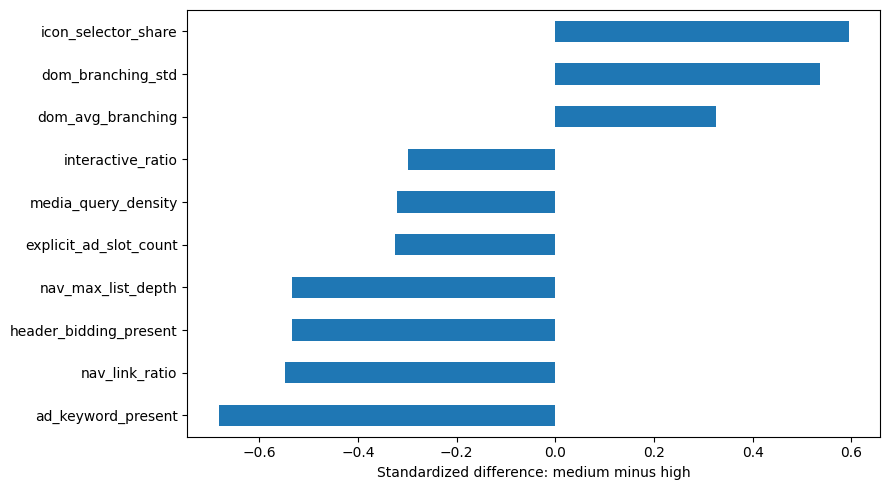

In [8]:
standardized_diffs = []

for col in feature_cols:
    high_values = X.loc[y == 0, col]
    medium_values = X.loc[y == 1, col]
    pooled_std = X[col].std()
    if pooled_std == 0 or np.isnan(pooled_std):
        diff = np.nan
    else:
        diff = (medium_values.mean() - high_values.mean()) / pooled_std
    standardized_diffs.append({
        "feature": col,
        "family": "DOM" if col in dom_cols else "CSS" if col in css_feature_cols else "Ad-density",
        "standardized_difference_medium_minus_high": diff,
        "abs_standardized_difference": abs(diff) if not np.isnan(diff) else np.nan,
    })

standardized_diffs_df = (
    pd.DataFrame(standardized_diffs)
    .sort_values("abs_standardized_difference", ascending=False)
    .reset_index(drop=True)
)

display(standardized_diffs_df.head(10))

ax = standardized_diffs_df.head(10).sort_values("standardized_difference_medium_minus_high").plot(
    kind="barh",
    x="feature",
    y="standardized_difference_medium_minus_high",
    legend=False,
    figsize=(9, 5),
)
ax.set_xlabel("Standardized difference: medium minus high")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

## 5. Tuning and evaluation setup

The table below summarizes the final tuning procedure used in the nested validation design.

In [10]:
tuning_overview = pd.DataFrame([
    {
        "Model": "Dummy majority classifier",
        "Hyperparameter tuning": "No",
        "Main search space": "Predicts majority class only",
        "Tuning metric": "Not applicable",
        "Threshold tuning": "Fixed at 0.50",
    },
    {
        "Model": "Random Forest",
        "Hyperparameter tuning": f"RandomizedSearchCV, {N_ITER_RF} iterations",
        "Main search space": "n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features",
        "Tuning metric": "Average precision",
        "Threshold tuning": "Inner-CV threshold search 0.25–0.60; selected by class-1 F1",
    },
    {
        "Model": "XGBoost",
        "Hyperparameter tuning": f"RandomizedSearchCV, {N_ITER_XGB} iterations",
        "Main search space": "n_estimators, max_depth, learning_rate, min_child_weight, subsample, colsample_bytree, gamma, reg_alpha, reg_lambda",
        "Tuning metric": "Average precision",
        "Threshold tuning": "Inner-CV threshold search 0.25–0.60; selected by class-1 F1",
    },
    {
        "Model": "Weighted XGBoost",
        "Hyperparameter tuning": f"RandomizedSearchCV, {N_ITER_XGB} iterations",
        "Main search space": "XGBoost parameters plus scale_pos_weight based on class ratio in outer-training fold",
        "Tuning metric": "Average precision",
        "Threshold tuning": "Inner-CV threshold search 0.25–0.60; selected by class-1 F1",
    },
    {
        "Model": "SMOTE-XGBoost",
        "Hyperparameter tuning": f"RandomizedSearchCV, {N_ITER_SMOTE_XGB} iterations",
        "Main search space": "SMOTE sampling_strategy, SMOTE k_neighbors, plus XGBoost parameters",
        "Tuning metric": "Average precision",
        "Threshold tuning": "Inner-CV threshold search 0.25–0.60; selected by class-1 F1",
    },
    {
        "Model": "TabPFN",
        "Hyperparameter tuning": "No randomized search",
        "Main search space": f"n_estimators = {TABPFN_N_ESTIMATORS}, where supported by installed version",
        "Tuning metric": "Not applicable",
        "Threshold tuning": "Inner-CV threshold search 0.10–0.90; selected by class-1 F1",
    },
])

display(tuning_overview)

,Model,Hyperparameter tuning,Main search space,Tuning metric,Threshold tuning
0,Dummy majority classifier,No,Predicts majority class only,Not applicable,Fixed at 0.50
1,Random Forest,"RandomizedSearchCV, 60 iterations","n_estimators, max_depth, min_samples_split, mi...",Average precision,Inner-CV threshold search 0.25–0.60; selected ...
2,XGBoost,"RandomizedSearchCV, 80 iterations","n_estimators, max_depth, learning_rate, min_ch...",Average precision,Inner-CV threshold search 0.25–0.60; selected ...
3,Weighted XGBoost,"RandomizedSearchCV, 80 iterations",XGBoost parameters plus scale_pos_weight based...,Average precision,Inner-CV threshold search 0.25–0.60; selected ...
4,SMOTE-XGBoost,"RandomizedSearchCV, 80 iterations","SMOTE sampling_strategy, SMOTE k_neighbors, pl...",Average precision,Inner-CV threshold search 0.25–0.60; selected ...
5,TabPFN,No randomized search,"n_estimators = 4, where supported by installed...",Not applicable,Inner-CV threshold search 0.10–0.90; selected ...


## 6. Helper functions for nested validation

The helper functions below implement metric calculation, threshold selection, randomized hyperparameter search, model specification, and nested stratified cross-validation.

In [11]:
def evaluate_metrics(y_true, y_proba, threshold):
    '''Evaluate binary classification metrics at a chosen threshold.'''
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_1": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_1": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "precision_0": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "recall_0": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1_0": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "average_precision": average_precision_score(y_true, y_proba),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


def choose_threshold(y_true_oof, y_proba_oof, thresholds):
    '''Select threshold by maximizing minority-class F1; ties use recall, then precision.'''
    rows = []
    for threshold in thresholds:
        y_pred = (y_proba_oof >= threshold).astype(int)
        rows.append({
            "threshold": threshold,
            "precision_1": precision_score(y_true_oof, y_pred, pos_label=1, zero_division=0),
            "recall_1": recall_score(y_true_oof, y_pred, pos_label=1, zero_division=0),
            "f1_1": f1_score(y_true_oof, y_pred, pos_label=1, zero_division=0),
            "macro_f1": f1_score(y_true_oof, y_pred, average="macro", zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_true_oof, y_pred),
        })
    threshold_df = (
        pd.DataFrame(rows)
        .sort_values(by=["f1_1", "recall_1", "precision_1"], ascending=[False, False, False])
        .reset_index(drop=True)
    )
    return float(threshold_df.loc[0, "threshold"]), threshold_df


def get_inner_oof_proba(estimator, X_train, y_train, inner_cv):
    '''Get inner-fold out-of-fold predicted probabilities for threshold tuning.'''
    return cross_val_predict(
        estimator=clone(estimator),
        X=X_train,
        y=y_train,
        cv=inner_cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]


def randomized_tune(estimator, param_dist, n_iter, X_train, y_train, inner_cv):
    '''Run randomized search with average precision as the selection metric.'''
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring="average_precision",
        cv=inner_cv,
        refit=True,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        error_score="raise",
        verbose=0,
    )
    search.fit(X_train, y_train)
    return search.best_estimator_, search.best_params_, search.best_score_

In [12]:
def make_tabpfn():
    '''Create TabPFN classifier while staying compatible with different package versions.'''
    if not TABPFN_AVAILABLE:
        raise ImportError("TabPFN is not installed or could not be imported.")
    try:
        return TabPFNClassifier(device="cpu", n_estimators=TABPFN_N_ESTIMATORS)
    except TypeError:
        try:
            return TabPFNClassifier(device="cpu")
        except TypeError:
            return TabPFNClassifier()


def tabpfn_inner_oof_and_test(X_train, y_train, X_test, inner_cv):
    '''Compute inner OOF probabilities and outer test probabilities for TabPFN.'''
    X_train_np = X_train.to_numpy(dtype=np.float32)
    y_train_np = y_train.to_numpy(dtype=int)
    X_test_np = X_test.to_numpy(dtype=np.float32)

    oof_proba = np.zeros(len(y_train), dtype=float)
    for inner_train_idx, inner_val_idx in inner_cv.split(X_train, y_train):
        model = make_tabpfn()
        model.fit(X_train_np[inner_train_idx], y_train_np[inner_train_idx])
        oof_proba[inner_val_idx] = model.predict_proba(X_train_np[inner_val_idx])[:, 1]

    final_model = make_tabpfn()
    final_model.fit(X_train_np, y_train_np)
    test_proba = final_model.predict_proba(X_test_np)[:, 1]
    return oof_proba, test_proba

In [13]:
def make_model_specs(y_train):
    '''Define estimators and search spaces for the current outer-training fold.'''
    ratio = (y_train == 0).sum() / (y_train == 1).sum()

    xgb_base = dict(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=1,
        tree_method="hist",
    )

    rf_param_dist = {
        "n_estimators": [200, 300, 500, 800],
        "max_depth": [None, 6, 10, 15, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 5, 10],
        "max_features": ["sqrt", "log2", 0.5],
    }

    xgb_param_dist = {
        "n_estimators": [100, 200, 300, 500, 800],
        "max_depth": [2, 3, 4, 5, 6],
        "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.10],
        "min_child_weight": [1, 3, 5, 10],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "gamma": [0, 0.1, 0.5, 1],
        "reg_alpha": [0, 0.1, 0.5, 1],
        "reg_lambda": [1, 3, 5, 10],
    }

    xgb_weighted_param_dist = {
        **xgb_param_dist,
        "scale_pos_weight": [0.50 * ratio, 0.75 * ratio, 1.00 * ratio, 1.25 * ratio, 1.50 * ratio, 2.00 * ratio],
    }

    smote_xgb_param_dist = {
        "smote__sampling_strategy": [0.4, 0.6, 0.8, 1.0],
        "smote__k_neighbors": [3, 5, 7],
        "xgb__n_estimators": [100, 200, 300, 500],
        "xgb__max_depth": [2, 3, 4, 5],
        "xgb__learning_rate": [0.01, 0.03, 0.05, 0.08],
        "xgb__min_child_weight": [1, 3, 5, 10],
        "xgb__subsample": [0.6, 0.8, 1.0],
        "xgb__colsample_bytree": [0.6, 0.8, 1.0],
        "xgb__gamma": [0, 0.1, 0.5],
        "xgb__reg_alpha": [0, 0.1, 0.5],
        "xgb__reg_lambda": [1, 3, 5],
    }

    specs = {
        "Dummy": {
            "estimator": DummyClassifier(strategy="most_frequent"),
            "param_dist": None,
            "n_iter": None,
            "tune_hyperparams": False,
            "tune_threshold": False,
            "thresholds": [0.50],
        },
        "Random Forest": {
            "estimator": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
            "param_dist": rf_param_dist,
            "n_iter": N_ITER_RF,
            "tune_hyperparams": True,
            "tune_threshold": True,
            "thresholds": TREE_THRESHOLDS,
        },
        "XGBoost": {
            "estimator": XGBClassifier(**xgb_base),
            "param_dist": xgb_param_dist,
            "n_iter": N_ITER_XGB,
            "tune_hyperparams": True,
            "tune_threshold": True,
            "thresholds": TREE_THRESHOLDS,
        },
        "Weighted XGBoost": {
            "estimator": XGBClassifier(**xgb_base),
            "param_dist": xgb_weighted_param_dist,
            "n_iter": N_ITER_XGB,
            "tune_hyperparams": True,
            "tune_threshold": True,
            "thresholds": TREE_THRESHOLDS,
        },
        "SMOTE-XGBoost": {
            "estimator": Pipeline([
                ("smote", SMOTE(random_state=RANDOM_STATE)),
                ("xgb", XGBClassifier(**xgb_base)),
            ]),
            "param_dist": smote_xgb_param_dist,
            "n_iter": N_ITER_SMOTE_XGB,
            "tune_hyperparams": True,
            "tune_threshold": True,
            "thresholds": TREE_THRESHOLDS,
        },
    }

    if RUN_TABPFN and TABPFN_AVAILABLE:
        specs["TabPFN"] = {
            "estimator": None,
            "param_dist": None,
            "n_iter": None,
            "tune_hyperparams": False,
            "tune_threshold": True,
            "thresholds": TABPFN_THRESHOLDS,
            "custom": "tabpfn",
        }

    return specs

In [14]:
def run_nested_model_comparison(X_input, y_input, model_names=None, output_prefix="optimized_nested"):
    '''
    Run nested stratified CV for selected models.

    Returns:
    - all_results_df: fold-level metrics for default and tuned thresholds
    - final_fold_results: final threshold selection per model/fold
    - best_params_df: best hyperparameters and chosen thresholds
    - threshold_details_df: inner-loop threshold results
    - predictions_df: outer-test predictions for PR curves, confusion matrix, and subgroup analysis
    - mean_table/std_table/thesis_table: formatted summaries
    '''
    X_input = X_input.apply(pd.to_numeric, errors="coerce")
    y_input = y_input.astype(int)

    if X_input.isna().sum().sum() > 0:
        raise ValueError("X_input contains missing values.")

    outer_cv = StratifiedKFold(n_splits=OUTER_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    all_results = []
    all_best_params = []
    all_threshold_details = []
    all_predictions = []

    start_all = time.perf_counter()

    for outer_fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_input, y_input), start=1):
        print("\n" + "=" * 80)
        print(f"OUTER FOLD {outer_fold}/{OUTER_SPLITS}")
        print("=" * 80)

        X_train = X_input.iloc[train_idx]
        y_train = y_input.iloc[train_idx]
        X_test = X_input.iloc[test_idx]
        y_test = y_input.iloc[test_idx]

        inner_cv = StratifiedKFold(n_splits=INNER_SPLITS, shuffle=True, random_state=RANDOM_STATE + outer_fold)
        specs = make_model_specs(y_train)

        if model_names is not None:
            specs = {name: spec for name, spec in specs.items() if name in model_names}

        for model_name, spec in specs.items():
            print(f"\nRunning {model_name}...")
            model_start = time.perf_counter()

            if spec.get("custom") == "tabpfn":
                inner_oof_proba, test_proba = tabpfn_inner_oof_and_test(
                    X_train=X_train,
                    y_train=y_train,
                    X_test=X_test,
                    inner_cv=inner_cv,
                )
                best_threshold, threshold_df = choose_threshold(
                    y_true_oof=y_train.to_numpy(),
                    y_proba_oof=inner_oof_proba,
                    thresholds=spec["thresholds"],
                )
                best_params = {
                    "model": model_name,
                    "outer_fold": outer_fold,
                    "best_inner_average_precision": np.nan,
                    "best_threshold": best_threshold,
                    "note": "TabPFN threshold tuned; no randomized hyperparameter search",
                }

            elif not spec["tune_hyperparams"]:
                final_model = clone(spec["estimator"])
                final_model.fit(X_train, y_train)
                test_proba = final_model.predict_proba(X_test)[:, 1]
                best_threshold = 0.50
                threshold_df = pd.DataFrame([{
                    "threshold": 0.50,
                    "precision_1": np.nan,
                    "recall_1": np.nan,
                    "f1_1": np.nan,
                    "macro_f1": np.nan,
                    "balanced_accuracy": np.nan,
                }])
                best_params = {
                    "model": model_name,
                    "outer_fold": outer_fold,
                    "best_inner_average_precision": np.nan,
                    "best_threshold": best_threshold,
                    "note": "Dummy baseline; no tuning",
                }

            else:
                best_estimator, best_param_dict, best_inner_score = randomized_tune(
                    estimator=spec["estimator"],
                    param_dist=spec["param_dist"],
                    n_iter=spec["n_iter"],
                    X_train=X_train,
                    y_train=y_train,
                    inner_cv=inner_cv,
                )
                inner_oof_proba = get_inner_oof_proba(
                    estimator=best_estimator,
                    X_train=X_train,
                    y_train=y_train,
                    inner_cv=inner_cv,
                )
                best_threshold, threshold_df = choose_threshold(
                    y_true_oof=y_train.to_numpy(),
                    y_proba_oof=inner_oof_proba,
                    thresholds=spec["thresholds"],
                )
                final_model = clone(best_estimator)
                final_model.fit(X_train, y_train)
                test_proba = final_model.predict_proba(X_test)[:, 1]
                best_params = {
                    "model": model_name,
                    "outer_fold": outer_fold,
                    "best_inner_average_precision": best_inner_score,
                    "best_threshold": best_threshold,
                    **best_param_dict,
                }

            threshold_df = threshold_df.copy()
            threshold_df["model"] = model_name
            threshold_df["outer_fold"] = outer_fold
            all_threshold_details.append(threshold_df)
            all_best_params.append(best_params)

            eval_thresholds = [("default_0.50", 0.50)]
            if model_name != "Dummy":
                eval_thresholds.append(("tuned", best_threshold))

            for evaluation_name, threshold in eval_thresholds:
                metrics = evaluate_metrics(y_true=y_test.to_numpy(), y_proba=test_proba, threshold=threshold)
                metrics.update({
                    "model": model_name,
                    "outer_fold": outer_fold,
                    "evaluation": evaluation_name,
                    "chosen_threshold": threshold,
                })
                all_results.append(metrics)

                y_pred = (test_proba >= threshold).astype(int)
                all_predictions.append(pd.DataFrame({
                    "row_index": X_input.index[test_idx],
                    "outer_fold": outer_fold,
                    "model": model_name,
                    "evaluation": evaluation_name,
                    "y_true": y_test.to_numpy(),
                    "y_proba": test_proba,
                    "y_pred": y_pred,
                }))

            elapsed_model = time.perf_counter() - model_start
            print(f"Finished {model_name} in {elapsed_model / 60:.2f} min. Best threshold: {best_threshold:.2f}")

    elapsed_all = time.perf_counter() - start_all
    print(f"\nTotal runtime: {elapsed_all / 60:.2f} minutes")

    all_results_df = pd.DataFrame(all_results)
    best_params_df = pd.DataFrame(all_best_params)
    threshold_details_df = pd.concat(all_threshold_details, ignore_index=True)
    predictions_df = pd.concat(all_predictions, ignore_index=True)

    metric_cols = [
        "accuracy", "precision_1", "recall_1", "f1_1",
        "precision_0", "recall_0", "f1_0",
        "macro_f1", "balanced_accuracy", "average_precision",
    ]

    final_rows = []
    for model_name in all_results_df["model"].unique():
        part = all_results_df[all_results_df["model"] == model_name]
        if model_name == "Dummy":
            final_rows.append(part[part["evaluation"] == "default_0.50"])
        else:
            final_rows.append(part[part["evaluation"] == "tuned"])
    final_fold_results = pd.concat(final_rows, ignore_index=True)

    model_order = ["Dummy", "Random Forest", "XGBoost", "Weighted XGBoost", "SMOTE-XGBoost", "TabPFN"]
    final_fold_results["model"] = pd.Categorical(final_fold_results["model"], categories=model_order, ordered=True)
    final_fold_results = final_fold_results.sort_values(["model", "outer_fold"])

    mean_table = final_fold_results.groupby("model", observed=True)[metric_cols].mean().round(3)
    std_table = final_fold_results.groupby("model", observed=True)[metric_cols].std().round(3)

    thesis_cols = ["accuracy", "precision_1", "recall_1", "f1_1", "macro_f1", "balanced_accuracy", "average_precision"]
    thesis_table = pd.DataFrame(index=mean_table.index)
    for col in thesis_cols:
        thesis_table[col] = [
            f"{mean_table.loc[idx, col]:.3f} ({std_table.loc[idx, col]:.3f})"
            for idx in mean_table.index
        ]
    thesis_table = thesis_table.rename(columns={
        "accuracy": "Accuracy",
        "precision_1": "Precision class 1",
        "recall_1": "Recall class 1",
        "f1_1": "F1 class 1",
        "macro_f1": "Macro-F1",
        "balanced_accuracy": "Balanced accuracy",
        "average_precision": "Average precision",
    })

    prefix = OUTPUT_DIR / output_prefix
    all_results_df.to_csv(f"{prefix}_all_thresholds.csv", index=False)
    final_fold_results.to_csv(f"{prefix}_final_fold_results.csv", index=False)
    best_params_df.to_csv(f"{prefix}_best_params.csv", index=False)
    threshold_details_df.to_csv(f"{prefix}_threshold_details.csv", index=False)
    predictions_df.to_csv(f"{prefix}_predictions.csv", index=False)
    mean_table.to_csv(f"{prefix}_mean.csv")
    std_table.to_csv(f"{prefix}_std.csv")
    thesis_table.to_csv(f"{prefix}_thesis_table_mean_sd.csv")

    with pd.ExcelWriter(f"{prefix}_model_comparison.xlsx", engine="openpyxl") as writer:
        all_results_df.to_excel(writer, sheet_name="All_thresholds", index=False)
        final_fold_results.to_excel(writer, sheet_name="Final_fold_results", index=False)
        best_params_df.to_excel(writer, sheet_name="Best_params", index=False)
        threshold_details_df.to_excel(writer, sheet_name="Threshold_details", index=False)
        predictions_df.to_excel(writer, sheet_name="Predictions", index=False)
        mean_table.to_excel(writer, sheet_name="Mean")
        std_table.to_excel(writer, sheet_name="Std")
        thesis_table.to_excel(writer, sheet_name="Thesis_mean_SD")

    return {
        "all_results_df": all_results_df,
        "final_fold_results": final_fold_results,
        "best_params_df": best_params_df,
        "threshold_details_df": threshold_details_df,
        "predictions_df": predictions_df,
        "mean_table": mean_table,
        "std_table": std_table,
        "thesis_table": thesis_table,
    }

## 7. Final nested model comparison

This is the final fair model comparison. Hyperparameters are selected inside the inner loop and performance is evaluated on held-out outer folds only.

Set `RUN_FINAL_MODEL_COMPARISON = True` to execute. TabPFN is included only when `RUN_TABPFN = True` and the package is available.

In [14]:
# ==========================================================
# Step 7: TabPFN-only tuned nested model comparison with progress
# ==========================================================

import os
import time

# Allow TabPFN on CPU with more than 1000 rows
os.environ["TABPFN_ALLOW_CPU_LARGE_DATASET"] = "1"

RUN_TABPFN = True
TABPFN_N_ESTIMATORS = 4

try:
    from tabpfn import TabPFNClassifier
    TABPFN_AVAILABLE = True
except ImportError:
    TABPFN_AVAILABLE = False
    raise ImportError(
        "TabPFN is not installed. Run `%pip install tabpfn`, restart the kernel, and rerun the notebook."
    )


def make_tabpfn():
    """Create TabPFN classifier while allowing datasets >1000 rows on CPU."""
    if not TABPFN_AVAILABLE:
        raise ImportError("TabPFN is not installed or could not be imported.")

    candidate_kwargs = [
        {
            "device": "cpu",
            "n_estimators": TABPFN_N_ESTIMATORS,
            "ignore_pretraining_limits": True,
        },
        {
            "device": "cpu",
            "ignore_pretraining_limits": True,
        },
        {
            "device": "cpu",
            "n_estimators": TABPFN_N_ESTIMATORS,
        },
        {
            "device": "cpu",
        },
        {},
    ]

    last_error = None

    for kwargs in candidate_kwargs:
        try:
            return TabPFNClassifier(**kwargs)
        except TypeError as e:
            last_error = e

    raise last_error


print("=" * 80)
print("Running TabPFN-only nested cross-validation")
print("=" * 80)

start_time = time.perf_counter()

tabpfn_nested_outputs = run_nested_model_comparison(
    X_input=X,
    y_input=y,
    model_names=["TabPFN"],
    output_prefix="final_nested_tabpfn_only",
)

elapsed_time = time.perf_counter() - start_time

print("=" * 80)
print(f"TabPFN-only nested CV finished in {elapsed_time / 60:.2f} minutes.")
print("=" * 80)


# ==========================================================
# Show fold-level tuned TabPFN results only
# ==========================================================

tabpfn_tuned_folds = tabpfn_nested_outputs["final_fold_results"].copy()
tabpfn_tuned_folds = tabpfn_tuned_folds[tabpfn_tuned_folds["model"] == "TabPFN"]

tabpfn_tuned_folds = tabpfn_tuned_folds[
    [
        "outer_fold",
        "evaluation",
        "chosen_threshold",
        "accuracy",
        "precision_1",
        "recall_1",
        "f1_1",
        "macro_f1",
        "balanced_accuracy",
        "average_precision",
    ]
].round(3)

display(tabpfn_tuned_folds)


# ==========================================================
# Show final thesis-style TabPFN tuned nested result only
# ==========================================================

tabpfn_tuned_nested = tabpfn_nested_outputs["thesis_table"].loc[["TabPFN"]]

display(tabpfn_tuned_nested)


Running TabPFN-only nested cross-validation

OUTER FOLD 1/5

Running TabPFN...


NameError: name 'tabpfn_inner_oof_and_test' is not defined

In [16]:
# ==========================================================
# Step 7: Full nested model comparison without TabPFN
# ==========================================================

RUN_FINAL_MODEL_COMPARISON = True
RUN_TABPFN = False  # Important: exclude TabPFN

NON_TABPFN_MODELS = [
    "Dummy",
    "Random Forest",
    "XGBoost",
    "Weighted XGBoost",
    "SMOTE-XGBoost",
]

if RUN_FINAL_MODEL_COMPARISON:
    final_outputs_no_tabpfn = run_nested_model_comparison(
        X_input=X,
        y_input=y,
        model_names=NON_TABPFN_MODELS,
        output_prefix="final_nested_without_tabpfn",
    )

    display(final_outputs_no_tabpfn["thesis_table"])
    display(final_outputs_no_tabpfn["mean_table"])
    display(final_outputs_no_tabpfn["std_table"])
else:
    print("Skipped final nested model comparison. Set RUN_FINAL_MODEL_COMPARISON = True to run.")


OUTER FOLD 1/5

Running Dummy...
Finished Dummy in 0.00 min. Best threshold: 0.50

Running Random Forest...
Finished Random Forest in 12.95 min. Best threshold: 0.25

Running XGBoost...
Finished XGBoost in 2.39 min. Best threshold: 0.25

Running Weighted XGBoost...
Finished Weighted XGBoost in 2.96 min. Best threshold: 0.40

Running SMOTE-XGBoost...


/Users/timvandegevel/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/timvandegevel/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/timvandegevel/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/timvandeg

Finished SMOTE-XGBoost in 1.96 min. Best threshold: 0.30

OUTER FOLD 2/5

Running Dummy...
Finished Dummy in 0.00 min. Best threshold: 0.50

Running Random Forest...
Finished Random Forest in 11.38 min. Best threshold: 0.30

Running XGBoost...
Finished XGBoost in 2.31 min. Best threshold: 0.25

Running Weighted XGBoost...
Finished Weighted XGBoost in 3.07 min. Best threshold: 0.35

Running SMOTE-XGBoost...


/Users/timvandegevel/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/timvandegevel/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/timvandegevel/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/timvandeg

Finished SMOTE-XGBoost in 1.92 min. Best threshold: 0.40

OUTER FOLD 3/5

Running Dummy...
Finished Dummy in 0.00 min. Best threshold: 0.50

Running Random Forest...
Finished Random Forest in 11.36 min. Best threshold: 0.30

Running XGBoost...
Finished XGBoost in 2.33 min. Best threshold: 0.30

Running Weighted XGBoost...
Finished Weighted XGBoost in 2.97 min. Best threshold: 0.45

Running SMOTE-XGBoost...


...

/Users/timvandegevel/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/timvandegevel/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/timvandegevel/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/timvandeg

Finished SMOTE-XGBoost in 2.09 min. Best threshold: 0.30

Total runtime: 94.55 minutes


,Accuracy,Precision class 1,Recall class 1,F1 class 1,Macro-F1,Balanced accuracy,Average precision
model,,,,,,,
Dummy,0.814 (0.000),0.000 (0.000),0.000 (0.000),0.000 (0.000),0.449 (0.000),0.500 (0.000),0.186 (0.000)
Random Forest,0.795 (0.031),0.470 (0.046),0.704 (0.047),0.562 (0.035),0.714 (0.028),0.760 (0.023),0.640 (0.041)
XGBoost,0.820 (0.009),0.513 (0.021),0.605 (0.052),0.554 (0.022),0.721 (0.012),0.737 (0.019),0.630 (0.036)
Weighted XGBoost,0.792 (0.030),0.467 (0.039),0.717 (0.082),0.562 (0.025),0.712 (0.022),0.763 (0.023),0.639 (0.030)
SMOTE-XGBoost,0.813 (0.019),0.500 (0.043),0.623 (0.079),0.552 (0.039),0.717 (0.024),0.740 (0.032),0.628 (0.037)


,accuracy,precision_1,recall_1,f1_1,precision_0,recall_0,f1_0,macro_f1,balanced_accuracy,average_precision
model,,,,,,,,,,
Dummy,0.814,0.000,0.000,0.000,0.814,1.000,0.898,0.449,0.500,0.186
Random Forest,0.795,0.470,0.704,0.562,0.924,0.816,0.866,0.714,0.760,0.640
XGBoost,0.820,0.513,0.605,0.554,0.906,0.868,0.887,0.721,0.737,0.630
Weighted XGBoost,0.792,0.467,0.717,0.562,0.927,0.809,0.863,0.712,0.763,0.639
SMOTE-XGBoost,0.813,0.500,0.623,0.552,0.909,0.856,0.882,0.717,0.740,0.628


,accuracy,precision_1,recall_1,f1_1,precision_0,recall_0,f1_0,macro_f1,balanced_accuracy,average_precision
model,,,,,,,,,,
Dummy,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Random Forest,0.031,0.046,0.047,0.035,0.010,0.042,0.024,0.028,0.023,0.041
XGBoost,0.009,0.021,0.052,0.022,0.010,0.018,0.007,0.012,0.019,0.036
Weighted XGBoost,0.030,0.039,0.082,0.025,0.016,0.052,0.025,0.022,0.023,0.030
SMOTE-XGBoost,0.019,0.043,0.079,0.039,0.015,0.031,0.014,0.024,0.032,0.037


## 8. Feature-family ablation analysis

This section evaluates the contribution of feature families. It includes:

1. standalone families: DOM only, CSS only, and ad-density only;  
2. the full feature set;  
3. leave-one-family-out configurations: full minus DOM, full minus CSS, and full minus ad-density.

Set `RUN_FEATURE_FAMILY_ANALYSIS = True` to execute. By default, the analysis uses Weighted XGBoost as the selected model, but this can be changed.

In [15]:
feature_configurations = {
    "DOM only": dom_cols,
    "CSS only": css_feature_cols,
    "Ad-density only": ad_cols,
    "Full feature set": feature_cols,
    "Full minus DOM": css_feature_cols + ad_cols,
    "Full minus CSS": dom_cols + ad_cols,
    "Full minus ad-density": dom_cols + css_feature_cols,
}

feature_config_table = pd.DataFrame([
    {"feature_configuration": name, "n_features": len(cols), "features": ", ".join(cols)}
    for name, cols in feature_configurations.items()
])

display(feature_config_table[["feature_configuration", "n_features"]])

,feature_configuration,n_features
0,DOM only,15
1,CSS only,8
2,Ad-density only,7
3,Full feature set,30
4,Full minus DOM,15
5,Full minus CSS,22
6,Full minus ad-density,23


In [26]:
# ============================================================
# TABPFN FEATURE-FAMILY ABLATION TABLE
#
# 0 = high credibility
# 1 = medium credibility
# Positive/minority class = medium credibility
#
# This runs only:
# - Full feature set
# - Full minus DOM hierarchy
# - Full minus CSS regularity
# - Full minus advertisement-density
#
# Model: TabPFN only
# Evaluation: nested stratified CV with inner threshold tuning
# ============================================================

import os
os.environ["TABPFN_ALLOW_CPU_LARGE_DATASET"] = "1"

import gc
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from IPython.display import display
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    balanced_accuracy_score,
)

from tabpfn import TabPFNClassifier


# ============================================================
# SETTINGS
# ============================================================

RANDOM_STATE = 42
OUTER_SPLITS = 5
INNER_SPLITS = 5

# Use same style as your TabPFN nested validation.
# If this is too slow, set TABPFN_N_ESTIMATORS = 1.
TABPFN_N_ESTIMATORS = 4

# Thresholds for inner-fold threshold tuning
THRESHOLDS = np.round(np.arange(0.10, 0.91, 0.01), 2)

# Threshold selection criterion
THRESHOLD_SELECTION_METRIC = "f1_1"

OUTPUT_DIR = Path("tabpfn_feature_family_ablation_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


# ============================================================
# CHECK REQUIRED VARIABLES
# ============================================================

required_objects = ["X", "y", "dom_cols", "css_feature_cols", "ad_cols"]

for obj in required_objects:
    if obj not in globals():
        raise NameError(
            f"{obj} is not defined. Please run the earlier notebook cells first."
        )


# Keep only columns that are actually present in X
dom_cols_valid = [c for c in dom_cols if c in X.columns]
css_cols_valid = [c for c in css_feature_cols if c in X.columns]
ad_cols_valid = [c for c in ad_cols if c in X.columns]

full_cols = dom_cols_valid + css_cols_valid + ad_cols_valid

print("Feature-family sizes:")
print(f"DOM hierarchy:         {len(dom_cols_valid)}")
print(f"CSS regularity:        {len(css_cols_valid)}")
print(f"Advertisement-density: {len(ad_cols_valid)}")
print(f"Full feature set:      {len(full_cols)}")


# ============================================================
# FEATURE ABLATION CONFIGURATIONS
# ============================================================

feature_configurations = {
    "Full feature set": full_cols,
    "Full minus DOM": css_cols_valid + ad_cols_valid,
    "Full minus CSS": dom_cols_valid + ad_cols_valid,
    "Full minus Ad-density": dom_cols_valid + css_cols_valid,
}

for config_name, cols in feature_configurations.items():
    if len(cols) == 0:
        raise ValueError(f"{config_name} has zero features. Check the feature-family lists.")

print("\nFeature configurations:")
for config_name, cols in feature_configurations.items():
    print(f"{config_name}: {len(cols)} features")


# ============================================================
# DEVICE SELECTION
# ============================================================

if torch.cuda.is_available():
    device = "cuda"
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("\nUsing device:", device)


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def clear_memory():
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        try:
            torch.mps.empty_cache()
        except Exception:
            pass


def make_tabpfn_model():
    """
    Creates a TabPFN model.
    The try/except makes this robust across TabPFN versions.
    """
    try:
        return TabPFNClassifier(
            device=device,
            ignore_pretraining_limits=True,
            n_estimators=TABPFN_N_ESTIMATORS,
        )
    except TypeError:
        return TabPFNClassifier(
            device=device,
            ignore_pretraining_limits=True,
        )


def predict_proba_class_1(model, X_input):
    """
    Safely extracts the predicted probability for class 1.
    """
    proba = model.predict_proba(X_input)

    if hasattr(model, "classes_"):
        classes = list(model.classes_)
        if 1 in classes:
            return proba[:, classes.index(1)]

    return proba[:, 1]


def compute_metrics(y_true, y_proba, threshold):
    """
    Computes minority-class and balanced evaluation metrics.
    """
    y_pred = (y_proba >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(y_true, y_pred),

        # Class 1: medium credibility
        "precision_1": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_1": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),

        # Overall balanced metrics
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),

        # Threshold-independent metric for class 1
        "average_precision": average_precision_score(y_true, y_proba),
    }


def choose_best_threshold(y_true_oof, y_proba_oof, thresholds):
    """
    Selects threshold using inner out-of-fold predictions.
    Main criterion: F1 class 1.
    Tie-breakers: macro-F1, balanced accuracy, recall class 1.
    """
    rows = []

    for threshold in thresholds:
        row = compute_metrics(
            y_true=y_true_oof,
            y_proba=y_proba_oof,
            threshold=threshold
        )
        row["threshold"] = threshold
        rows.append(row)

    threshold_df = pd.DataFrame(rows)

    sort_cols = [
        THRESHOLD_SELECTION_METRIC,
        "macro_f1",
        "balanced_accuracy",
        "recall_1",
        "precision_1",
    ]

    threshold_df = (
        threshold_df
        .sort_values(by=sort_cols, ascending=[False] * len(sort_cols))
        .reset_index(drop=True)
    )

    best_threshold = float(threshold_df.loc[0, "threshold"])

    return best_threshold, threshold_df


def make_mean_sd_table(mean_df, std_df, metric_cols):
    """
    Creates thesis-style mean (SD) table.
    """
    formatted = pd.DataFrame(index=mean_df.index)

    formatted["Number of features"] = mean_df["n_features"].astype(int)

    for col in metric_cols:
        formatted[col] = [
            f"{mean_df.loc[idx, col]:.3f} ({std_df.loc[idx, col]:.3f})"
            for idx in mean_df.index
        ]

    return formatted


# ============================================================
# RUN TABPFN FEATURE-FAMILY ABLATION
# ============================================================

outer_cv = StratifiedKFold(
    n_splits=OUTER_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

all_results = []
all_threshold_details = []
all_predictions = []

start_time = time.perf_counter()

for config_name, selected_cols in feature_configurations.items():

    print("\n" + "=" * 80)
    print(f"Running TabPFN ablation: {config_name}")
    print(f"Number of features: {len(selected_cols)}")
    print("=" * 80)

    X_config = (
        X[selected_cols]
        .replace([np.inf, -np.inf], np.nan)
        .apply(pd.to_numeric, errors="coerce")
    )

    if X_config.isna().sum().sum() > 0:
        raise ValueError(
            f"Missing values found in {config_name}. "
            "Please handle missing values before running ablation."
        )

    X_work = X_config.astype("float32").reset_index(drop=True)
    y_work = pd.Series(y).astype(int).reset_index(drop=True)

    for outer_fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_work, y_work), start=1):

        print(f"\n{config_name} | outer fold {outer_fold}/{OUTER_SPLITS}")

        X_train_outer = X_work.iloc[train_idx].reset_index(drop=True)
        y_train_outer = y_work.iloc[train_idx].reset_index(drop=True)

        X_test_outer = X_work.iloc[test_idx].reset_index(drop=True)
        y_test_outer = y_work.iloc[test_idx].reset_index(drop=True)

        inner_cv = StratifiedKFold(
            n_splits=INNER_SPLITS,
            shuffle=True,
            random_state=RANDOM_STATE + outer_fold
        )

        # ----------------------------------------------------
        # Inner CV: get out-of-fold probabilities for threshold tuning
        # ----------------------------------------------------

        inner_oof_proba = np.zeros(len(y_train_outer), dtype=float)

        for inner_train_idx, inner_val_idx in inner_cv.split(X_train_outer, y_train_outer):

            X_inner_train = X_train_outer.iloc[inner_train_idx]
            y_inner_train = y_train_outer.iloc[inner_train_idx]

            X_inner_val = X_train_outer.iloc[inner_val_idx]

            model_inner = make_tabpfn_model()
            model_inner.fit(X_inner_train, y_inner_train)

            inner_oof_proba[inner_val_idx] = predict_proba_class_1(
                model_inner,
                X_inner_val
            )

            del model_inner
            clear_memory()

        best_threshold, threshold_df = choose_best_threshold(
            y_true_oof=y_train_outer.to_numpy(),
            y_proba_oof=inner_oof_proba,
            thresholds=THRESHOLDS
        )

        threshold_df["feature_configuration"] = config_name
        threshold_df["n_features"] = len(selected_cols)
        threshold_df["outer_fold"] = outer_fold

        all_threshold_details.append(threshold_df)

        # ----------------------------------------------------
        # Outer test evaluation
        # ----------------------------------------------------

        final_model = make_tabpfn_model()
        final_model.fit(X_train_outer, y_train_outer)

        test_proba = predict_proba_class_1(
            final_model,
            X_test_outer
        )

        metrics = compute_metrics(
            y_true=y_test_outer.to_numpy(),
            y_proba=test_proba,
            threshold=best_threshold
        )

        metrics.update({
            "feature_configuration": config_name,
            "n_features": len(selected_cols),
            "outer_fold": outer_fold,
            "chosen_threshold": best_threshold,
        })

        all_results.append(metrics)

        y_test_pred = (test_proba >= best_threshold).astype(int)

        all_predictions.append(pd.DataFrame({
            "feature_configuration": config_name,
            "n_features": len(selected_cols),
            "outer_fold": outer_fold,
            "original_index": X.index[test_idx],
            "y_true": y_test_outer.to_numpy(),
            "y_proba": test_proba,
            "y_pred": y_test_pred,
            "chosen_threshold": best_threshold,
        }))

        print(
            f"Finished fold {outer_fold}: "
            f"threshold={best_threshold:.2f}, "
            f"F1 class 1={metrics['f1_1']:.3f}, "
            f"AP={metrics['average_precision']:.3f}"
        )

        del final_model
        clear_memory()

elapsed = time.perf_counter() - start_time

print("\n" + "=" * 80)
print(f"TabPFN feature-family ablation completed in {elapsed / 60:.2f} minutes")
print("=" * 80)


# ============================================================
# CREATE ABLATION TABLES
# ============================================================

results_df = pd.DataFrame(all_results)
threshold_details_df = pd.concat(all_threshold_details, ignore_index=True)
predictions_df = pd.concat(all_predictions, ignore_index=True)

metric_cols = [
    "accuracy",
    "precision_1",
    "recall_1",
    "f1_1",
    "macro_f1",
    "balanced_accuracy",
    "average_precision",
]

mean_df = (
    results_df
    .groupby("feature_configuration")[["n_features"] + metric_cols]
    .mean()
)

std_df = (
    results_df
    .groupby("feature_configuration")[metric_cols]
    .std()
)

row_order = [
    "Full feature set",
    "Full minus DOM",
    "Full minus CSS",
    "Full minus Ad-density",
]

mean_df = mean_df.reindex(row_order)
std_df = std_df.reindex(row_order)

mean_table = mean_df.copy()
mean_table["n_features"] = mean_table["n_features"].astype(int)
mean_table = mean_table.round(3)

thesis_table_mean_sd = make_mean_sd_table(
    mean_df=mean_df,
    std_df=std_df,
    metric_cols=metric_cols
)

thesis_table_mean_sd = thesis_table_mean_sd.rename(columns={
    "accuracy": "Accuracy",
    "precision_1": "Precision class 1",
    "recall_1": "Recall class 1",
    "f1_1": "F1 class 1",
    "macro_f1": "Macro F1",
    "balanced_accuracy": "Balanced accuracy",
    "average_precision": "Average precision",
})

print("\nTabPFN feature-family ablation table: mean (SD)")
display(thesis_table_mean_sd)


# ============================================================
# DELTA TABLE RELATIVE TO FULL FEATURE SET
# ============================================================

full_row = mean_df.loc["Full feature set", metric_cols]

delta_table = (
    mean_df[metric_cols]
    .subtract(full_row, axis=1)
    .round(3)
)

delta_table = delta_table.rename(columns={
    "accuracy": "Δ Accuracy",
    "precision_1": "Δ Precision class 1",
    "recall_1": "Δ Recall class 1",
    "f1_1": "Δ F1 class 1",
    "macro_f1": "Δ Macro F1",
    "balanced_accuracy": "Δ Balanced accuracy",
    "average_precision": "Δ Average precision",
})

print("\nTabPFN feature-family ablation: difference relative to full feature set")
display(delta_table)


# ============================================================
# SAVE OUTPUTS
# ============================================================

results_df.to_csv(
    OUTPUT_DIR / "tabpfn_feature_family_ablation_split_results.csv",
    index=False
)

threshold_details_df.to_csv(
    OUTPUT_DIR / "tabpfn_feature_family_ablation_threshold_details.csv",
    index=False
)

predictions_df.to_csv(
    OUTPUT_DIR / "tabpfn_feature_family_ablation_predictions.csv",
    index=False
)

mean_table.to_csv(
    OUTPUT_DIR / "tabpfn_feature_family_ablation_mean_table.csv"
)

thesis_table_mean_sd.to_csv(
    OUTPUT_DIR / "tabpfn_feature_family_ablation_thesis_table_mean_sd.csv"
)

delta_table.to_csv(
    OUTPUT_DIR / "tabpfn_feature_family_ablation_delta_vs_full.csv"
)


Feature-family sizes:
DOM hierarchy:         15
CSS regularity:        8
Advertisement-density: 7
Full feature set:      30

Feature configurations:
Full feature set: 30 features
Full minus DOM: 15 features
Full minus CSS: 22 features
Full minus Ad-density: 23 features

Using device: cpu

Running TabPFN ablation: Full feature set
Number of features: 30

Full feature set | outer fold 1/5


: 

## 9. Load or select final prediction results

The next analyses use outer-test predictions from the final nested comparison. If the comparison has been run in this notebook, predictions are taken from memory. Otherwise, load the saved CSV file.

In [20]:
PREDICTIONS_PATH = OUTPUT_DIR / "final_nested_all_models_predictions.csv"
FINAL_FOLD_RESULTS_PATH = OUTPUT_DIR / "final_nested_all_models_final_fold_results.csv"

if "final_outputs" in globals():
    predictions_for_analysis = final_outputs["predictions_df"].copy()
    final_fold_results_for_analysis = final_outputs["final_fold_results"].copy()
elif PREDICTIONS_PATH.exists() and FINAL_FOLD_RESULTS_PATH.exists():
    predictions_for_analysis = pd.read_csv(PREDICTIONS_PATH)
    final_fold_results_for_analysis = pd.read_csv(FINAL_FOLD_RESULTS_PATH)
else:
    predictions_for_analysis = None
    final_fold_results_for_analysis = None
    print("No final prediction file found yet. Run Section 7 or update PREDICTIONS_PATH.")

if predictions_for_analysis is not None:
    display(predictions_for_analysis.head())

,row_index,outer_fold,model,evaluation,y_true,y_proba,y_pred
0,1,1,TabPFN,default_0.50,0,0.512578,1
1,4,1,TabPFN,default_0.50,0,0.258663,0
2,5,1,TabPFN,default_0.50,1,0.283771,0
3,6,1,TabPFN,default_0.50,1,0.309415,0
4,15,1,TabPFN,default_0.50,0,0.454198,0


## 10. Precision-recall curves

Precision-recall curves are plotted from the outer-test predicted probabilities. Thresholds do not affect the curve itself; average precision is reported as the PR-based summary metric.

Loaded: fixed_models_nested_predictions.csv
Loaded: optimized_nested_all_models_predictions.csv
Loaded: tabpfn_nested_outputs_overnight_clean/tabpfn_nested_cv_outer_test_predictions.csv

Models included in PR curve:
['Random Forest', 'XGBoost', 'Weighted XGBoost', 'SMOTE-XGBoost', 'TabPFN']


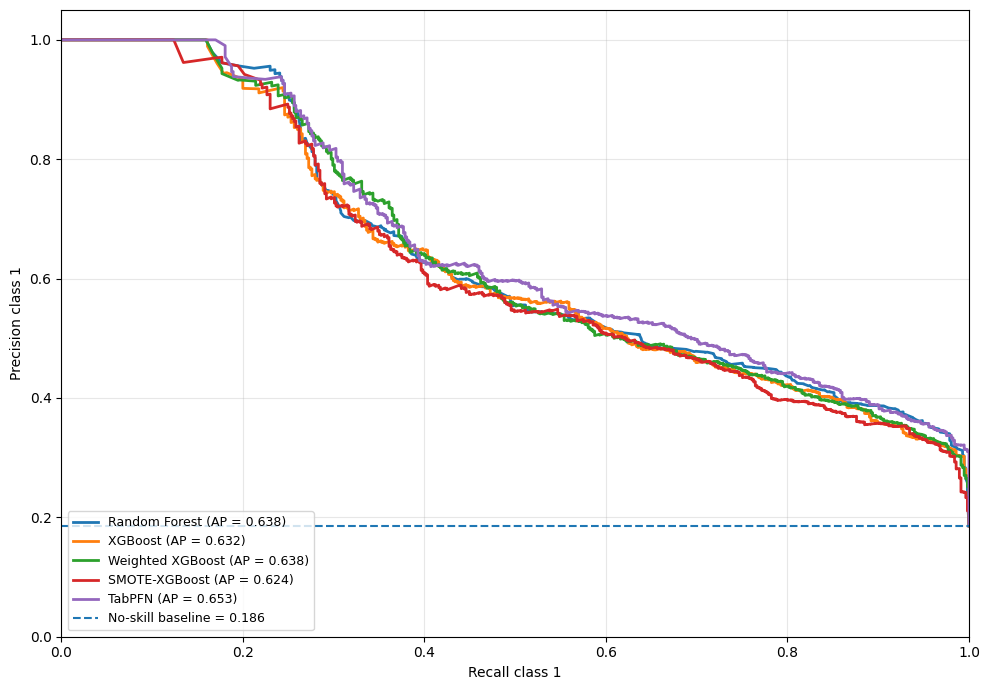


PR-AUC / Average Precision summary:


,model,n_predictions,n_class_1,prevalence_class_1,average_precision_pooled,pr_auc_trapezoid_pooled,average_precision_mean_outer_folds,average_precision_sd_outer_folds
0,TabPFN,3044,565,0.186,0.653,0.653,0.655,0.026
1,Random Forest,3044,565,0.186,0.638,0.639,0.639,0.048
2,Weighted XGBoost,3044,565,0.186,0.638,0.638,0.639,0.030
3,XGBoost,3044,565,0.186,0.632,0.632,0.632,0.037
4,SMOTE-XGBoost,3044,565,0.186,0.624,0.624,0.628,0.037



Saved outputs to:
- pr_auc_all_models_outputs/precision_recall_curves_all_models.png
- pr_auc_all_models_outputs/precision_recall_curves_all_models.pdf
- pr_auc_all_models_outputs/pr_auc_average_precision_summary.csv
- pr_auc_all_models_outputs/precision_recall_curve_points.csv


In [9]:
# ============================================================
# PRECISION-RECALL CURVES / PR-AUC FOR ALL FINAL MODELS
#
# This cell:
# 1. Collects saved outer-test predictions for the final models
# 2. Uses y_true and y_proba only, so thresholds do not affect the curve
# 3. Plots all precision-recall curves in one graph
# 4. Reports Average Precision, used as PR-AUC-style metric in the thesis
#
# Class 1 = medium credibility
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    auc
)

# ============================================================
# SETTINGS
# ============================================================

PR_OUTPUT_DIR = "pr_auc_all_models_outputs"
os.makedirs(PR_OUTPUT_DIR, exist_ok=True)

MODEL_ORDER = [
    "Random Forest",
    "XGBoost",
    "Weighted XGBoost",
    "SMOTE-XGBoost",
    "TabPFN",
]

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def standardise_prediction_columns(df):
    df = df.copy()

    rename_map = {
        "row_index": "original_index",
        "index": "original_index",
        "true_label": "y_true",
        "target": "y_true",
        "actual": "y_true",
        "proba": "y_proba",
        "proba_1": "y_proba",
        "probability": "y_proba",
        "probability_1": "y_proba",
        "y_score": "y_proba",
        "score": "y_proba",
    }

    df = df.rename(
        columns={c: rename_map[c] for c in df.columns if c in rename_map}
    )

    return df


def standardise_model_names(df):
    df = df.copy()

    model_map = {
        "RandomForest_fixed": "Random Forest",
        "RF_balanced_fixed": "Balanced Random Forest",
        "XGBoost_fixed": "XGBoost",
        "XGB_weighted": "Weighted XGBoost",
        "XGB_weighted_nested_tuned": "Weighted XGBoost",
        "SMOTE_XGB": "SMOTE-XGBoost",
        "SMOTE_XGB_nested_tuned": "SMOTE-XGBoost",
        "TabPFN_nested_tuned": "TabPFN",
        "TABPFN_nested_tuned": "TabPFN",
        "TAPfpn_nested_tuned": "TabPFN",
    }

    if "model" in df.columns:
        df["model"] = df["model"].replace(model_map)

    if "evaluation" in df.columns and "model" not in df.columns:
        df["model"] = df["evaluation"].replace(model_map)

    return df


def keep_final_evaluation(df):
    """
    Keeps one prediction set per model.
    PR curves only need probabilities, so tuned/default thresholds do not change the curve.
    However, this removes duplicate rows caused by storing both default and tuned evaluations.
    """
    df = df.copy()

    if "evaluation" not in df.columns:
        return df

    kept = []

    for model_name, group in df.groupby("model"):
        group = group.copy()
        evaluations = group["evaluation"].astype(str)

        if model_name == "Dummy":
            preferred = group[evaluations.eq("default_0.50")]
            if len(preferred) == 0:
                preferred = group
        else:
            preferred = group[evaluations.eq("tuned")]
            if len(preferred) == 0:
                preferred = group[evaluations.str.contains("tuned", case=False, na=False)]
            if len(preferred) == 0:
                preferred = group[evaluations.eq("default_0.50")]
            if len(preferred) == 0:
                preferred = group

        kept.append(preferred)

    return pd.concat(kept, ignore_index=True)


def load_prediction_file(possible_paths):
    for path in possible_paths:
        if os.path.exists(path):
            print(f"Loaded: {path}")
            return pd.read_csv(path)

    return None


def prepare_prediction_df(df, source_name):
    df = standardise_prediction_columns(df)
    df = standardise_model_names(df)

    if "model" not in df.columns:
        raise ValueError(f"{source_name} does not contain a model column.")

    required_cols = ["y_true", "y_proba"]
    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        raise ValueError(f"{source_name} is missing required columns: {missing_cols}")

    df = keep_final_evaluation(df)

    df["y_true"] = df["y_true"].astype(int)
    df["y_proba"] = df["y_proba"].astype(float)

    if "original_index" in df.columns:
        df = df.drop_duplicates(subset=["model", "original_index"], keep="last")
    else:
        df = df.drop_duplicates()

    return df


# ============================================================
# LOAD AVAILABLE MODEL PREDICTIONS
# ============================================================

prediction_parts = []

# ------------------------------------------------------------
# 1. Fixed-model predictions:
# Dummy, Random Forest, Balanced RF, XGBoost
# ------------------------------------------------------------

fixed_df = None

if "fixed_predictions_df" in globals():
    print("Using fixed_predictions_df from notebook memory.")
    fixed_df = fixed_predictions_df.copy()
else:
    fixed_df = load_prediction_file([
        "fixed_models_nested_predictions.csv",
    ])

if fixed_df is not None:
    fixed_df = prepare_prediction_df(fixed_df, "fixed model predictions")
    prediction_parts.append(fixed_df)


# ------------------------------------------------------------
# 2. Optimized all-model predictions:
# usually contains Weighted XGBoost and SMOTE-XGBoost
# ------------------------------------------------------------

optimized_df = None

if "optimized_predictions_df" in globals():
    print("Using optimized_predictions_df from notebook memory.")
    optimized_df = optimized_predictions_df.copy()
else:
    optimized_df = load_prediction_file([
        "optimized_nested_all_models_predictions.csv",
    ])

if optimized_df is not None:
    optimized_df = prepare_prediction_df(optimized_df, "optimized model predictions")

    # If fixed predictions exist, use optimized predictions mainly for these two models.
    # This avoids duplicate Random Forest / XGBoost curves if both files exist.
    if fixed_df is not None:
        optimized_df = optimized_df[
            optimized_df["model"].isin(["Weighted XGBoost", "SMOTE-XGBoost"])
        ].copy()

    if len(optimized_df) > 0:
        prediction_parts.append(optimized_df)


# ------------------------------------------------------------
# 3. TabPFN predictions
# ------------------------------------------------------------

tabpfn_df = None

if "tabpfn_outer_predictions" in globals():
    print("Using tabpfn_outer_predictions from notebook memory.")
    tabpfn_df = tabpfn_outer_predictions.copy()
else:
    tabpfn_df = load_prediction_file([
        "tabpfn_nested_outputs_overnight_clean/tabpfn_nested_cv_outer_test_predictions.csv",
        "tabpfn_nested_outputs/tabpfn_nested_cv_outer_test_predictions.csv",
        "tabpfn_nested_cv_outer_test_predictions.csv",
    ])

if tabpfn_df is not None:
    tabpfn_df = standardise_prediction_columns(tabpfn_df)

    if "model" not in tabpfn_df.columns:
        tabpfn_df["model"] = "TabPFN"

    tabpfn_df = prepare_prediction_df(tabpfn_df, "TabPFN predictions")
    prediction_parts.append(tabpfn_df)


# ============================================================
# COMBINE PREDICTIONS
# ============================================================

if len(prediction_parts) == 0:
    raise FileNotFoundError(
        "No prediction files were found. Run the nested model evaluation cells first."
    )

pr_predictions_df = pd.concat(prediction_parts, ignore_index=True)

# Exclude Balanced Random Forest from the PR-AUC plot
# Exclude Dummy and Balanced Random Forest from the PR-AUC plot
pr_predictions_df = pr_predictions_df[
    ~pr_predictions_df["model"].isin(["Dummy", "Balanced Random Forest"])
].copy()
# Keep only models with valid probabilities
pr_predictions_df = pr_predictions_df.dropna(subset=["y_true", "y_proba", "model"])

# Remove duplicate model-source rows if present
if "original_index" in pr_predictions_df.columns:
    pr_predictions_df = pr_predictions_df.drop_duplicates(
        subset=["model", "original_index"],
        keep="last"
    )

available_models = [
    model for model in MODEL_ORDER
    if model in pr_predictions_df["model"].unique()
]

extra_models = [
    model for model in pr_predictions_df["model"].unique()
    if model not in available_models
]

available_models = available_models + sorted(extra_models)

print("\nModels included in PR curve:")
print(available_models)

missing_models = [m for m in MODEL_ORDER if m not in pr_predictions_df["model"].unique()]
if missing_models:
    print("\nModels not found and therefore not plotted:")
    print(missing_models)


# ============================================================
# PLOT PRECISION-RECALL CURVES
# ============================================================

plt.figure(figsize=(10, 7))

summary_rows = []
curve_rows = []

for model_name in available_models:
    model_df = pr_predictions_df[pr_predictions_df["model"] == model_name].copy()

    y_true_model = model_df["y_true"].astype(int).to_numpy()
    y_proba_model = model_df["y_proba"].astype(float).to_numpy()

    precision, recall, thresholds = precision_recall_curve(
        y_true_model,
        y_proba_model
    )

    average_precision = average_precision_score(
        y_true_model,
        y_proba_model
    )

    # Trapezoidal PR-AUC. Average precision is usually preferred for imbalanced data,
    # but both are saved for transparency.
    pr_auc_trapezoid = auc(recall[::-1], precision[::-1])

    if "outer_fold" in model_df.columns:
        fold_ap = (
            model_df
            .groupby("outer_fold")
            .apply(lambda g: average_precision_score(g["y_true"], g["y_proba"]))
        )
        mean_fold_ap = fold_ap.mean()
        std_fold_ap = fold_ap.std()
    else:
        mean_fold_ap = np.nan
        std_fold_ap = np.nan

    summary_rows.append({
        "model": model_name,
        "n_predictions": len(model_df),
        "n_class_1": int(np.sum(y_true_model == 1)),
        "prevalence_class_1": float(np.mean(y_true_model == 1)),
        "average_precision_pooled": average_precision,
        "pr_auc_trapezoid_pooled": pr_auc_trapezoid,
        "average_precision_mean_outer_folds": mean_fold_ap,
        "average_precision_sd_outer_folds": std_fold_ap,
    })

    curve_df = pd.DataFrame({
        "model": model_name,
        "recall": recall,
        "precision": precision,
    })
    curve_rows.append(curve_df)

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{model_name} (AP = {average_precision:.3f})"
    )

# No-skill baseline: prevalence of class 1
overall_prevalence = np.mean(pr_predictions_df.drop_duplicates(
    subset=["original_index"] if "original_index" in pr_predictions_df.columns else None
)["y_true"] == 1) if "original_index" in pr_predictions_df.columns else np.mean(pr_predictions_df["y_true"] == 1)

plt.axhline(
    overall_prevalence,
    linestyle="--",
    linewidth=1.5,
    label=f"No-skill baseline = {overall_prevalence:.3f}"
)

plt.xlabel("Recall class 1")
plt.ylabel("Precision class 1")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend(loc="lower left", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(PR_OUTPUT_DIR, "precision_recall_curves_all_models.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(PR_OUTPUT_DIR, "precision_recall_curves_all_models.pdf"),
    bbox_inches="tight"
)

plt.show()


# ============================================================
# DISPLAY AND SAVE SUMMARY TABLES
# ============================================================

pr_summary_df = pd.DataFrame(summary_rows)

pr_summary_df = pr_summary_df.sort_values(
    by="average_precision_pooled",
    ascending=False
).reset_index(drop=True)

pr_curves_df = pd.concat(curve_rows, ignore_index=True)

print("\nPR-AUC / Average Precision summary:")
display(pr_summary_df.round(3))

pr_predictions_df.to_csv(
    os.path.join(PR_OUTPUT_DIR, "pr_curve_predictions_used.csv"),
    index=False
)

pr_summary_df.to_csv(
    os.path.join(PR_OUTPUT_DIR, "pr_auc_average_precision_summary.csv"),
    index=False
)

pr_curves_df.to_csv(
    os.path.join(PR_OUTPUT_DIR, "precision_recall_curve_points.csv"),
    index=False
)

print("\nSaved outputs to:")
print(f"- {PR_OUTPUT_DIR}/precision_recall_curves_all_models.png")
print(f"- {PR_OUTPUT_DIR}/precision_recall_curves_all_models.pdf")
print(f"- {PR_OUTPUT_DIR}/pr_auc_average_precision_summary.csv")
print(f"- {PR_OUTPUT_DIR}/precision_recall_curve_points.csv")

## 11. Confusion matrix for the final model

Set `FINAL_MODEL_NAME` to the model used for the final thesis interpretation. Use `"auto"` to select the model with the highest mean class-1 F1-score across outer folds.

Loaded prediction dataframe from file: tabpfn_feature_family_ablation_outputs/tabpfn_feature_family_ablation_predictions.csv

Available columns:
['feature_configuration', 'n_features', 'outer_fold', 'original_index', 'y_true', 'y_proba', 'y_pred', 'chosen_threshold']

Feature-configuration column found: feature_configuration
Available feature configurations:


feature_configuration
Full feature set         3044
Full minus DOM           3044
Full minus CSS           3044
Full minus Ad-density    3044
Name: count, dtype: int64


Filtered to feature configuration: Full feature set

Rows used for final confusion matrix: 3044
Class distribution:


y_true
0    2479
1     565
Name: count, dtype: int64


FOLD-LEVEL METRICS FROM SELECTED FULL FEATURE SET PREDICTIONS


...

,mean,std
accuracy,0.810,0.026
precision_1,0.498,0.042
recall_1,0.704,0.059
f1_1,0.581,0.021
macro_f1,0.729,0.020
balanced_accuracy,0.770,0.014
average_precision,0.655,0.026



Expected approximately:
Accuracy            0.810
Precision class 1   0.498
Recall class 1      0.704
F1 class 1          0.581
Macro F1            0.729
Balanced accuracy   0.770
Average precision   0.655

POOLED METRICS FOR CONFUSION MATRIX


,n_predictions,n_class_0,n_class_1,TN,FP,FN,TP,pooled_accuracy,pooled_precision_1,pooled_recall_1,pooled_f1_1,pooled_macro_f1,pooled_balanced_accuracy,pooled_average_precision
0,3044,2479,565,2069,410,167,398,0.81,0.493,0.704,0.58,0.729,0.77,0.653



Confusion matrix counts:


,Predicted high credibility (0),Predicted medium credibility (1)
Actual high credibility (0),2069,410
Actual medium credibility (1),167,398


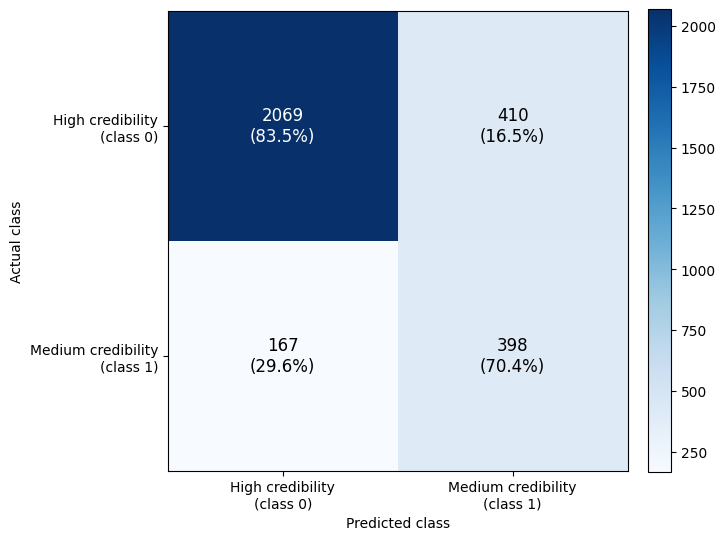


Saved outputs to:
- tabpfn_full_feature_confusion_matrix/tabpfn_full_feature_confusion_matrix_blue.png
- tabpfn_full_feature_confusion_matrix/tabpfn_full_feature_confusion_matrix_blue.pdf
- tabpfn_full_feature_confusion_matrix/tabpfn_full_feature_confusion_matrix_counts.csv
- tabpfn_full_feature_confusion_matrix/tabpfn_full_feature_confusion_matrix_metrics.csv


In [10]:
# ============================================================
# FIXED CONFUSION MATRIX FOR FINAL TABPFN FULL FEATURE SET
#
# This code forces the confusion matrix to use:
# Feature configuration = Full feature set
# Final model = TabPFN
#
# It also prints a metric check so you can verify that the
# fold-level metrics match your main TabPFN row:
# Accuracy ~ 0.810
# Precision ~ 0.498
# Recall ~ 0.704
# F1 ~ 0.581
# Macro F1 ~ 0.729
# Balanced accuracy ~ 0.770
# Average precision ~ 0.655
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    balanced_accuracy_score
)

CM_OUTPUT_DIR = "tabpfn_full_feature_confusion_matrix"
os.makedirs(CM_OUTPUT_DIR, exist_ok=True)

TARGET_FEATURE_CONFIG = "Full feature set"
TARGET_MODEL_NAMES = [
    "TabPFN",
    "TabPFN_nested_tuned",
    "TABPFN_nested_tuned",
    "TAPfpn_nested_tuned"
]

CLASS_LABELS = [
    "High credibility\n(class 0)",
    "Medium credibility\n(class 1)"
]


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def standardise_prediction_columns(df):
    df = df.copy()

    rename_map = {
        "row_index": "original_index",
        "index": "original_index",
        "true_label": "y_true",
        "target": "y_true",
        "actual": "y_true",
        "prediction": "y_pred",
        "pred": "y_pred",
        "predicted": "y_pred",
        "proba": "y_proba",
        "proba_1": "y_proba",
        "probability": "y_proba",
        "probability_1": "y_proba",
        "y_score": "y_proba",
        "score": "y_proba",
    }

    return df.rename(columns={c: rename_map[c] for c in df.columns if c in rename_map})


def find_feature_config_column(df):
    candidates = [
        "feature_configuration",
        "feature_config",
        "configuration",
        "config",
        "feature_set",
        "ablation",
    ]

    for col in candidates:
        if col in df.columns:
            return col

    return None


def find_prediction_source():
    """
    Prefer the feature-family prediction dataframe, because it should contain
    the Full feature set and ablation configurations.
    """

    memory_candidates = [
        "feature_family_predictions_df",
        "ablation_predictions_df",
        "tabpfn_feature_family_predictions_df",
        "predictions_df",
        "final_predictions_df",
        "tabpfn_predictions_df",
    ]

    for name in memory_candidates:
        if name in globals() and isinstance(globals()[name], pd.DataFrame):
            temp = standardise_prediction_columns(globals()[name].copy())
            if "y_true" in temp.columns and ("y_pred" in temp.columns or "y_proba" in temp.columns):
                print(f"Using prediction dataframe from notebook memory: {name}")
                return temp

    file_patterns = [
        "**/*feature*family*prediction*.csv",
        "**/*ablation*prediction*.csv",
        "**/*tabpfn*prediction*.csv",
        "**/*prediction*.csv",
    ]

    candidate_files = []
    for pattern in file_patterns:
        candidate_files.extend(glob.glob(pattern, recursive=True))

    candidate_files = list(dict.fromkeys(candidate_files))

    for path in candidate_files:
        try:
            temp = pd.read_csv(path)
            temp = standardise_prediction_columns(temp)

            if "y_true" in temp.columns and ("y_pred" in temp.columns or "y_proba" in temp.columns):
                print(f"Loaded prediction dataframe from file: {path}")
                return temp

        except Exception:
            pass

    raise FileNotFoundError(
        "Could not find a prediction dataframe containing y_true and y_pred/y_proba."
    )


def make_y_pred_if_needed(preds):
    preds = preds.copy()

    if "y_pred" in preds.columns:
        preds["y_pred"] = preds["y_pred"].astype(int)
        return preds

    if "y_proba" not in preds.columns:
        raise ValueError("Need either y_pred or y_proba to create predictions.")

    if "chosen_threshold" in preds.columns:
        preds["y_pred"] = (
            preds["y_proba"].astype(float) >= preds["chosen_threshold"].astype(float)
        ).astype(int)
        print("Created y_pred using chosen_threshold column.")

    elif "threshold" in preds.columns:
        preds["y_pred"] = (
            preds["y_proba"].astype(float) >= preds["threshold"].astype(float)
        ).astype(int)
        print("Created y_pred using threshold column.")

    else:
        preds["y_pred"] = (preds["y_proba"].astype(float) >= 0.50).astype(int)
        print("Created y_pred using threshold 0.50. Check whether this is intended.")

    return preds


def compute_fold_metrics(preds):
    fold_rows = []

    for fold, g in preds.groupby("outer_fold"):
        yt = g["y_true"].astype(int)
        yp = g["y_pred"].astype(int)

        row = {
            "outer_fold": fold,
            "n": len(g),
            "accuracy": accuracy_score(yt, yp),
            "precision_1": precision_score(yt, yp, pos_label=1, zero_division=0),
            "recall_1": recall_score(yt, yp, pos_label=1, zero_division=0),
            "f1_1": f1_score(yt, yp, pos_label=1, zero_division=0),
            "macro_f1": f1_score(yt, yp, average="macro", zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(yt, yp),
        }

        if "y_proba" in g.columns:
            row["average_precision"] = average_precision_score(
                yt,
                g["y_proba"].astype(float)
            )

        fold_rows.append(row)

    fold_metrics = pd.DataFrame(fold_rows)
    fold_summary = fold_metrics.drop(columns=["outer_fold", "n"]).agg(["mean", "std"]).T

    return fold_metrics, fold_summary


# ============================================================
# LOAD AND FILTER PREDICTIONS
# ============================================================

preds_all = find_prediction_source()
preds_all = standardise_prediction_columns(preds_all)

print("\nAvailable columns:")
print(list(preds_all.columns))

# ------------------------------------------------------------
# Filter to Full feature set
# ------------------------------------------------------------

feature_col = find_feature_config_column(preds_all)

if feature_col is not None:
    print(f"\nFeature-configuration column found: {feature_col}")
    print("Available feature configurations:")
    display(preds_all[feature_col].value_counts(dropna=False))

    preds = preds_all[
        preds_all[feature_col].astype(str).str.strip().str.lower()
        == TARGET_FEATURE_CONFIG.lower()
    ].copy()

    if len(preds) == 0:
        raise ValueError(
            f"No rows found for feature configuration: {TARGET_FEATURE_CONFIG}. "
            "Check the available configurations printed above."
        )

    print(f"\nFiltered to feature configuration: {TARGET_FEATURE_CONFIG}")

else:
    preds = preds_all.copy()
    print(
        "\nNo feature-configuration column found. "
        "Using the loaded prediction dataframe as-is."
    )

# ------------------------------------------------------------
# Filter to TabPFN / final model if model columns exist
# ------------------------------------------------------------

if "model" in preds.columns:
    print("\nAvailable model values:")
    display(preds["model"].value_counts(dropna=False))

    model_mask = preds["model"].astype(str).isin(TARGET_MODEL_NAMES)

    if model_mask.any():
        preds = preds[model_mask].copy()
        print("Filtered to TabPFN model rows.")

if "evaluation" in preds.columns:
    print("\nAvailable evaluation values:")
    display(preds["evaluation"].value_counts(dropna=False))

    evaluation_mask = preds["evaluation"].astype(str).isin(TARGET_MODEL_NAMES)

    if evaluation_mask.any():
        preds = preds[evaluation_mask].copy()
        print("Filtered to TabPFN nested tuned evaluation rows.")

# ------------------------------------------------------------
# Remove duplicates carefully
# ------------------------------------------------------------

if "outer_fold" in preds.columns and "original_index" in preds.columns:
    preds = preds.drop_duplicates(subset=["outer_fold", "original_index"], keep="last")
elif "original_index" in preds.columns:
    preds = preds.drop_duplicates(subset=["original_index"], keep="last")
else:
    preds = preds.drop_duplicates()

preds["y_true"] = preds["y_true"].astype(int)

if "y_proba" in preds.columns:
    preds["y_proba"] = preds["y_proba"].astype(float)

preds = make_y_pred_if_needed(preds)

print("\nRows used for final confusion matrix:", len(preds))
print("Class distribution:")
display(preds["y_true"].value_counts().sort_index())


# ============================================================
# METRIC CHECK
# ============================================================

if "outer_fold" not in preds.columns:
    raise ValueError(
        "No outer_fold column found. Cannot check fold-level metrics against your main table."
    )

fold_metrics, fold_summary = compute_fold_metrics(preds)

print("\n" + "=" * 80)
print("FOLD-LEVEL METRICS FROM SELECTED FULL FEATURE SET PREDICTIONS")
print("=" * 80)
display(fold_metrics.round(3))

print("\n" + "=" * 80)
print("MEAN AND SD ACROSS OUTER FOLDS")
print("=" * 80)
display(fold_summary.round(3))

print("\nExpected approximately:")
print("Accuracy            0.810")
print("Precision class 1   0.498")
print("Recall class 1      0.704")
print("F1 class 1          0.581")
print("Macro F1            0.729")
print("Balanced accuracy   0.770")
print("Average precision   0.655")


# ============================================================
# CONFUSION MATRIX
# ============================================================

y_true = preds["y_true"].astype(int).to_numpy()
y_pred = preds["y_pred"].astype(int).to_numpy()

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

pooled_metrics = pd.DataFrame([{
    "n_predictions": len(preds),
    "n_class_0": int((y_true == 0).sum()),
    "n_class_1": int((y_true == 1).sum()),
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp,
    "pooled_accuracy": accuracy_score(y_true, y_pred),
    "pooled_precision_1": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
    "pooled_recall_1": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
    "pooled_f1_1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    "pooled_macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    "pooled_balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    "pooled_average_precision": average_precision_score(
        y_true,
        preds["y_proba"].astype(float)
    ) if "y_proba" in preds.columns else np.nan
}])

print("\n" + "=" * 80)
print("POOLED METRICS FOR CONFUSION MATRIX")
print("=" * 80)
display(pooled_metrics.round(3))

cm_df = pd.DataFrame(
    cm,
    index=["Actual high credibility (0)", "Actual medium credibility (1)"],
    columns=["Predicted high credibility (0)", "Predicted medium credibility (1)"]
)

print("\nConfusion matrix counts:")
display(cm_df)


# ============================================================
# PLOT CONFUSION MATRIX
# ============================================================

row_sums = cm.sum(axis=1, keepdims=True)
cm_row_pct = cm / row_sums

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm, cmap="Blues")

ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(CLASS_LABELS)
ax.set_yticklabels(CLASS_LABELS)

threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text_color = "white" if cm[i, j] > threshold else "black"
        ax.text(
            j,
            i,
            f"{cm[i, j]}\n({cm_row_pct[i, j]:.1%})",
            ha="center",
            va="center",
            color=text_color,
            fontsize=12
        )

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()

plt.savefig(
    os.path.join(CM_OUTPUT_DIR, "tabpfn_full_feature_confusion_matrix_blue.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(CM_OUTPUT_DIR, "tabpfn_full_feature_confusion_matrix_blue.pdf"),
    bbox_inches="tight"
)

plt.show()


# ============================================================
# SAVE OUTPUTS
# ============================================================

preds.to_csv(
    os.path.join(CM_OUTPUT_DIR, "tabpfn_full_feature_predictions_used.csv"),
    index=False
)

cm_df.to_csv(
    os.path.join(CM_OUTPUT_DIR, "tabpfn_full_feature_confusion_matrix_counts.csv")
)

pooled_metrics.to_csv(
    os.path.join(CM_OUTPUT_DIR, "tabpfn_full_feature_confusion_matrix_metrics.csv"),
    index=False
)

fold_metrics.to_csv(
    os.path.join(CM_OUTPUT_DIR, "tabpfn_full_feature_fold_metrics.csv"),
    index=False
)

print("\nSaved outputs to:")
print(f"- {CM_OUTPUT_DIR}/tabpfn_full_feature_confusion_matrix_blue.png")
print(f"- {CM_OUTPUT_DIR}/tabpfn_full_feature_confusion_matrix_blue.pdf")
print(f"- {CM_OUTPUT_DIR}/tabpfn_full_feature_confusion_matrix_counts.csv")
print(f"- {CM_OUTPUT_DIR}/tabpfn_full_feature_confusion_matrix_metrics.csv")

## 12. Subgroup error analysis

This analysis checks whether the final model performs differently across source characteristics such as media type or country. Country and media type are not used as predictors in the main models; they are only used here for post-hoc error analysis.

Using corrected final TabPFN predictions from notebook variable: preds

Prediction rows: 3044
Class distribution:


y_true
0    2479
1     565
Name: count, dtype: int64


Check: corrected full-feature TabPFN pooled metrics


,TN,FP,FN,TP,accuracy,precision_1,recall_1,f1_1,macro_f1,balanced_accuracy,average_precision
0,2069,410,167,398,0.81,0.493,0.704,0.58,0.729,0.77,0.653



Expected approximately:
Accuracy           ~ 0.810
Precision class 1  ~ 0.493 pooled / 0.498 fold mean
Recall class 1     ~ 0.704
F1 class 1         ~ 0.580
Balanced accuracy  ~ 0.770

Using metadata from notebook dataframe: df
Country column found: country
Media type column found: media-type

Merged predictions with metadata using original_index.

Rows after metadata merge: 3044


...

,subgroup,n,n_high_credibility_0,n_medium_credibility_1,prevalence_class_1,accuracy,precision_1,recall_1,f1_1,average_precision_1,macro_f1,balanced_accuracy,tn,fp,fn,tp,false_positive_rate,false_negative_rate,share_flagged_medium
0,Newspaper,877,837,40,0.046,0.933,0.333,0.475,0.392,0.437,0.678,0.715,799,38,21,19,0.045,0.525,0.065
1,Website,699,488,211,0.302,0.667,0.465,0.687,0.554,0.448,0.644,0.672,321,167,66,145,0.342,0.313,0.446
2,Organization/foundation,612,479,133,0.217,0.663,0.338,0.571,0.425,0.333,0.593,0.630,330,149,57,76,0.311,0.429,0.368
4,Journal,221,131,90,0.407,0.982,0.957,1.000,0.978,1.000,0.981,0.985,127,4,0,90,0.031,0.000,0.425
5,Radio station,191,140,51,0.267,0.906,0.754,0.961,0.845,0.903,0.889,0.923,124,16,2,49,0.114,0.039,0.340
6,Magazine,117,94,23,0.197,0.692,0.333,0.565,0.419,0.390,0.605,0.644,68,26,10,13,0.277,0.435,0.333
7,News agency,17,13,4,0.235,0.706,0.429,0.750,0.545,0.708,0.664,0.721,9,4,1,3,0.308,0.250,0.412



COUNTRY GROUPS EXCLUDED FROM MAIN TABLE DUE TO LOW SUPPORT


,subgroup,n,n_medium_credibility_1,prevalence_class_1,f1_1,balanced_accuracy
1,Canada,302,8,0.026,0.296,0.724
4,Australia,31,2,0.065,0.000,0.293
5,France,25,2,0.080,0.000,0.370
6,India,24,13,0.542,0.417,0.420
7,Germany,21,3,0.143,0.444,0.722
...,...,...,...,...,...,...
63,Estonia,1,0,0.000,0.000,NaN
64,Guam (Us Territory),1,0,0.000,0.000,NaN
65,Latvia,1,0,0.000,0.000,NaN
66,Malta,1,0,0.000,0.000,NaN



MEDIA-TYPE GROUPS EXCLUDED FROM MAIN TABLE DUE TO LOW SUPPORT


,subgroup,n,n_medium_credibility_1,prevalence_class_1,f1_1,balanced_accuracy
7,News agency,17,4,0.235,0.545,0.721


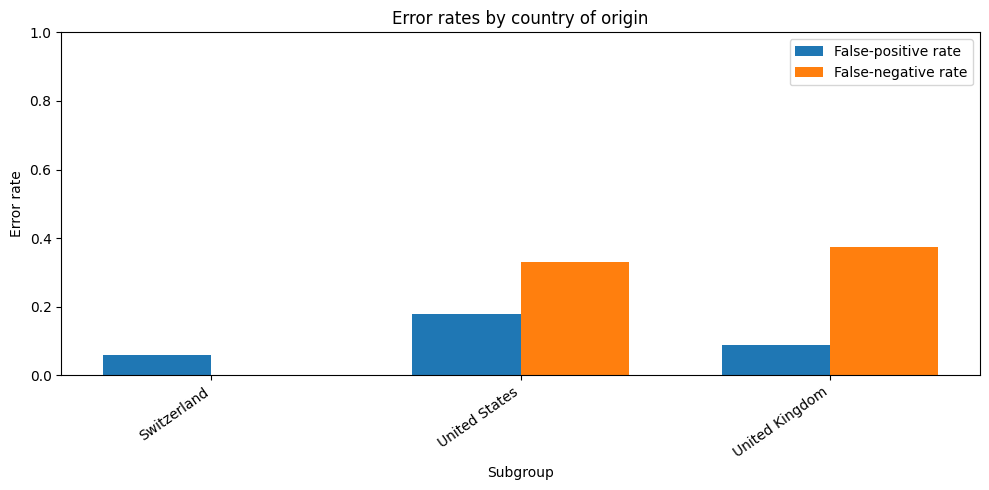

Saved: rq3_corrected_tabpfn_subgroup_analysis/rq3_country_error_rates.png
Saved: rq3_corrected_tabpfn_subgroup_analysis/rq3_country_error_rates.pdf


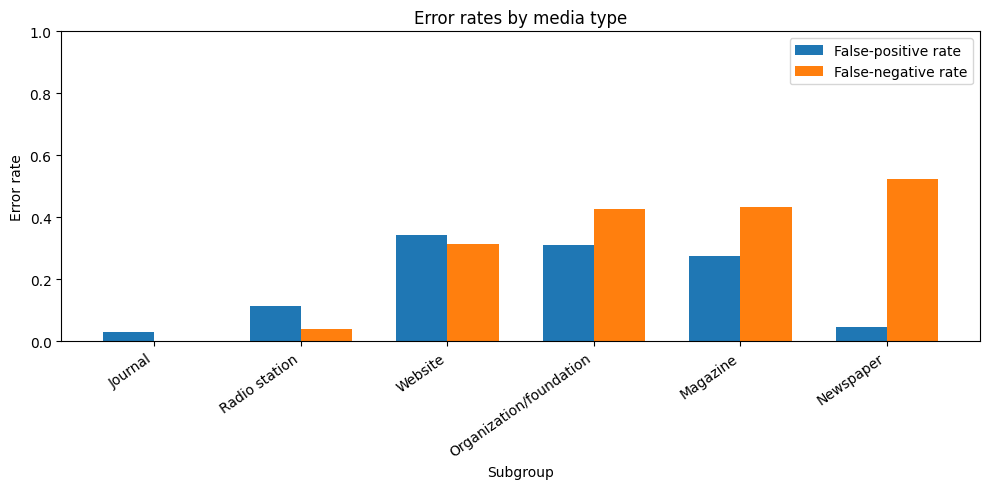

Saved: rq3_corrected_tabpfn_subgroup_analysis/rq3_media_type_error_rates.png
Saved: rq3_corrected_tabpfn_subgroup_analysis/rq3_media_type_error_rates.pdf

Saved outputs to:
- rq3_corrected_tabpfn_subgroup_analysis/rq3_country_main_results_table.csv
- rq3_corrected_tabpfn_subgroup_analysis/rq3_media_type_main_results_table.csv
- rq3_corrected_tabpfn_subgroup_analysis/rq3_country_all_full_metrics.csv
- rq3_corrected_tabpfn_subgroup_analysis/rq3_media_type_all_full_metrics.csv
- rq3_corrected_tabpfn_subgroup_analysis/rq3_predictions_with_metadata.csv
- rq3_corrected_tabpfn_subgroup_analysis/rq3_country_error_rates.png
- rq3_corrected_tabpfn_subgroup_analysis/rq3_media_type_error_rates.png


In [25]:
# ============================================================
# RQ3 / ERROR ANALYSIS:
# SUBGROUP ERROR ANALYSIS FOR FINAL TABPFN FULL-FEATURE MODEL
#
# Uses the corrected final TabPFN predictions:
# - Full feature set
# - Pooled outer-test predictions
#
# Class 0 = high credibility
# Class 1 = medium credibility
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    balanced_accuracy_score,
)

# ============================================================
# SETTINGS
# ============================================================
RQ3_OUTPUT_DIR = "rq3_corrected_tabpfn_subgroup_analysis"
os.makedirs(RQ3_OUTPUT_DIR, exist_ok=True)

# Only show subgroups in the main Results section when they have enough support
MIN_SUBGROUP_N = 100
MIN_MEDIUM_N   = 10

COUNTRY_COL_CANDIDATES = [
    "country", "Country", "country_of_origin", "Country of Origin",
    "country_origin", "origin_country", "mbfc_country", "source_country",
]
MEDIA_TYPE_COL_CANDIDATES = [
    "media-type", "media_type", "Media type", "media type", "type", "source_type",
]

# ============================================================
# 1. LOAD THE CORRECT FINAL TABPFN PREDICTIONS
# ============================================================
def load_correct_tabpfn_predictions():
    if "preds" in globals():
        temp = preds.copy()
        required = {"y_true", "y_pred"}
        if required.issubset(temp.columns):
            print("Using corrected final TabPFN predictions from notebook variable: preds")
            return temp

    path = "tabpfn_full_feature_confusion_matrix/tabpfn_full_feature_predictions_used.csv"
    if os.path.exists(path):
        print(f"Loaded corrected final TabPFN predictions from: {path}")
        return pd.read_csv(path)

    raise FileNotFoundError(
        "Could not find corrected full-feature TabPFN predictions. "
        "Run the corrected confusion-matrix code first."
    )

preds_rq3 = load_correct_tabpfn_predictions()

# Basic checks
required_cols = ["y_true", "y_pred"]
missing = [c for c in required_cols if c not in preds_rq3.columns]
if missing:
    raise ValueError(f"Missing required prediction columns: {missing}")

preds_rq3["y_true"] = preds_rq3["y_true"].astype(int)
preds_rq3["y_pred"] = preds_rq3["y_pred"].astype(int)
if "y_proba" in preds_rq3.columns:
    preds_rq3["y_proba"] = preds_rq3["y_proba"].astype(float)

print("\nPrediction rows:", len(preds_rq3))
print("Class distribution:")
display(preds_rq3["y_true"].value_counts().sort_index())

# ============================================================
# 2. CHECK THAT THESE ARE THE RIGHT TABPFN FULL-FEATURE RESULTS
# ============================================================
cm_check      = confusion_matrix(preds_rq3["y_true"], preds_rq3["y_pred"], labels=[0, 1])
tn, fp, fn, tp = cm_check.ravel()

check_metrics = pd.DataFrame([{
    "TN": tn, "FP": fp, "FN": fn, "TP": tp,
    "accuracy":     accuracy_score(preds_rq3["y_true"], preds_rq3["y_pred"]),
    "precision_1":  precision_score(preds_rq3["y_true"], preds_rq3["y_pred"], pos_label=1, zero_division=0),
    "recall_1":     recall_score(preds_rq3["y_true"], preds_rq3["y_pred"], pos_label=1, zero_division=0),
    "f1_1":         f1_score(preds_rq3["y_true"], preds_rq3["y_pred"], pos_label=1, zero_division=0),
    "macro_f1":     f1_score(preds_rq3["y_true"], preds_rq3["y_pred"], average="macro", zero_division=0),
    "balanced_accuracy": balanced_accuracy_score(preds_rq3["y_true"], preds_rq3["y_pred"]),
    "average_precision": (
        average_precision_score(preds_rq3["y_true"], preds_rq3["y_proba"])
        if "y_proba" in preds_rq3.columns else np.nan
    ),
}])

print("\nCheck: corrected full-feature TabPFN pooled metrics")
display(check_metrics.round(3))
print("\nExpected approximately:")
print("Accuracy           ~ 0.810")
print("Precision class 1  ~ 0.493 pooled / 0.498 fold mean")
print("Recall class 1     ~ 0.704")
print("F1 class 1         ~ 0.580")
print("Balanced accuracy  ~ 0.770")

# ============================================================
# 3. MERGE METADATA: COUNTRY AND MEDIA TYPE
# ============================================================
def find_column(df, candidates, label):
    for col in candidates:
        if col in df.columns:
            print(f"{label} column found:", col)
            return col
    lower_map = {c.lower(): c for c in df.columns}
    for col in candidates:
        if col.lower() in lower_map:
            print(f"{label} column found:", lower_map[col.lower()])
            return lower_map[col.lower()]
    raise ValueError(
        f"Could not find {label} column. "
        f"Available columns are: {list(df.columns)}"
    )

# Use existing df if available, otherwise load original dataset
if "df" in globals():
    metadata_source = df.copy()
    print("\nUsing metadata from notebook dataframe: df")
else:
    metadata_path = "scs_feature_table_final_3044.csv"
    if not os.path.exists(metadata_path):
        raise FileNotFoundError(
            "Could not find df in memory or scs_feature_table_final_3044.csv."
        )
    metadata_source = pd.read_csv(metadata_path)
    print(f"\nLoaded metadata from: {metadata_path}")

country_col = find_column(metadata_source, COUNTRY_COL_CANDIDATES,    "Country")
media_col   = find_column(metadata_source, MEDIA_TYPE_COL_CANDIDATES, "Media type")

metadata = metadata_source[[country_col, media_col]].copy()
metadata = metadata.reset_index().rename(columns={"index": "original_index"})
metadata[country_col] = metadata[country_col].fillna("Unknown").astype(str)
metadata[media_col]   = metadata[media_col].fillna("Unknown").astype(str)

# Merge predictions with metadata
if country_col in preds_rq3.columns and media_col in preds_rq3.columns:
    subgroup_df = preds_rq3.copy()
    print("\nPredictions already contain country and media-type metadata.")

elif "original_index" in preds_rq3.columns:
    subgroup_df = preds_rq3.merge(metadata, on="original_index", how="left")
    print("\nMerged predictions with metadata using original_index.")

else:
    if len(preds_rq3) != len(metadata_source):
        raise ValueError(
            "No original_index column found, and prediction length does not match df length. "
            "Cannot safely merge metadata."
        )
    subgroup_df = preds_rq3.copy().reset_index(drop=True)
    subgroup_df[country_col] = metadata_source[country_col].values
    subgroup_df[media_col]   = metadata_source[media_col].values
    print("\nMerged metadata by row order. Check that this is correct.")

print("\nRows after metadata merge:", len(subgroup_df))
display(subgroup_df[[country_col, media_col, "y_true", "y_pred"]].head())

# ============================================================
# 4. CLEAN COUNTRY AND MEDIA-TYPE LABELS
# ============================================================
def clean_country_label(x):
    x     = str(x).strip()
    x_low = x.lower()
    country_map = {
        "usa": "United States", "u.s.": "United States", "u.s.a.": "United States",
        "united states": "United States", "united states of america": "United States",
        "us": "United States", "uk": "United Kingdom", "u.k.": "United Kingdom",
        "united kingdom": "United Kingdom", "great britain": "United Kingdom",
        "england": "United Kingdom", "canada": "Canada", "switzerland": "Switzerland",
        "australia": "Australia", "france": "France", "india": "India",
        "germany": "Germany", "unknown": "Unknown", "nan": "Unknown", "": "Unknown",
    }
    x_no_paren = x_low.split("(")[0].strip()
    if x_low      in country_map: return country_map[x_low]
    if x_no_paren in country_map: return country_map[x_no_paren]
    return x.title()

def clean_media_type_label(x):
    x = str(x).strip().lower()
    if x in ["", "nan", "unknown"]:           return "Unknown"
    if "newspaper"   in x:                    return "Newspaper"
    if "website"     in x or "web site" in x: return "Website"
    if "journal"     in x:                    return "Journal"
    if "magazine"    in x:                    return "Magazine"
    if "radio"       in x:                    return "Radio station"
    if "organization" in x or "organisation" in x or "foundation" in x:
                                               return "Organization/foundation"
    if "news agency" in x or "wire" in x:     return "News agency"
    if "mixed"       in x or "other" in x:    return "Mixed/other"
    return x.title()

subgroup_df["country_clean"]    = subgroup_df[country_col].apply(clean_country_label)
subgroup_df["media_type_clean"] = subgroup_df[media_col].apply(clean_media_type_label)

print("\nCleaned country distribution:")
display(subgroup_df["country_clean"].value_counts().head(15).to_frame("n"))
print("\nCleaned media-type distribution:")
display(subgroup_df["media_type_clean"].value_counts().to_frame("n"))

# ============================================================
# 5. SUBGROUP METRIC FUNCTION
# ============================================================
def subgroup_metrics(data, subgroup_col):
    rows = []
    for subgroup, g in data.groupby(subgroup_col):
        y_true = g["y_true"].astype(int)
        y_pred = g["y_pred"].astype(int)
        n        = len(g)
        n_high   = int((y_true == 0).sum())
        n_medium = int((y_true == 1).sum())
        prevalence_1 = n_medium / n if n > 0 else np.nan

        cm_sg          = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn_s, fp_s, fn_s, tp_s = cm_sg.ravel()
        fpr = fp_s / (fp_s + tn_s) if (fp_s + tn_s) > 0 else np.nan
        fnr = fn_s / (fn_s + tp_s) if (fn_s + tp_s) > 0 else np.nan

        row = {
            "subgroup":               subgroup,
            "n":                      n,
            "n_high_credibility_0":   n_high,
            "n_medium_credibility_1": n_medium,
            "prevalence_class_1":     prevalence_1,
            "accuracy":               accuracy_score(y_true, y_pred),
            "precision_1":            precision_score(y_true, y_pred, pos_label=1, zero_division=0),
            "recall_1":               recall_score(y_true, y_pred, pos_label=1, zero_division=0),
            "f1_1":                   f1_score(y_true, y_pred, pos_label=1, zero_division=0),
            "macro_f1":               f1_score(y_true, y_pred, average="macro", zero_division=0),
            "balanced_accuracy": (
                balanced_accuracy_score(y_true, y_pred)
                if len(np.unique(y_true)) == 2 else np.nan
            ),
            "tn": tn_s, "fp": fp_s, "fn": fn_s, "tp": tp_s,
            "false_positive_rate":    fpr,
            "false_negative_rate":    fnr,
            "share_flagged_medium":   (y_pred == 1).mean(),
        }

        if "y_proba" in g.columns and len(np.unique(y_true)) == 2:
            row["average_precision_1"] = average_precision_score(
                y_true, g["y_proba"].astype(float)
            )
        else:
            row["average_precision_1"] = np.nan

        rows.append(row)

    result = pd.DataFrame(rows)
    result = result.sort_values(["n", "n_medium_credibility_1"], ascending=False)
    return result.reset_index(drop=True)


country_all = subgroup_metrics(subgroup_df, "country_clean")
media_all   = subgroup_metrics(subgroup_df, "media_type_clean")
# Remove TV station from media-type subgroup analysis
media_all = media_all[
    ~media_all["subgroup"].str.lower().str.contains("tv", na=False)
].copy()

# Main Results tables: only subgroups with enough support
country_main = country_all[
    (country_all["n"] >= MIN_SUBGROUP_N) &
    (country_all["n_medium_credibility_1"] >= MIN_MEDIUM_N)
].copy()

media_main = media_all[
    (media_all["n"] >= MIN_SUBGROUP_N) &
    (media_all["n_medium_credibility_1"] >= MIN_MEDIUM_N)
].copy()

country_excluded = country_all[
    ~(
        (country_all["n"] >= MIN_SUBGROUP_N) &
        (country_all["n_medium_credibility_1"] >= MIN_MEDIUM_N)
    )
].copy()

media_excluded = media_all[
    ~(
        (media_all["n"] >= MIN_SUBGROUP_N) &
        (media_all["n_medium_credibility_1"] >= MIN_MEDIUM_N)
    )
].copy()

# ============================================================
# 6. DISPLAY THESIS-FRIENDLY TABLES
# ============================================================
main_cols = [
    "subgroup", "n", "n_medium_credibility_1", "prevalence_class_1",
    "precision_1", "recall_1", "f1_1", "balanced_accuracy",
    "false_positive_rate", "false_negative_rate",
]

print("\n" + "=" * 100)
print("RQ3 TABLE 1 — COUNTRY OF ORIGIN SUBGROUP ERROR ANALYSIS")
print("=" * 100)
display(country_main[main_cols].round(3))

print("\n" + "=" * 100)
print("RQ3 TABLE 2 — MEDIA-TYPE SUBGROUP ERROR ANALYSIS")
print("=" * 100)
display(media_main[main_cols].round(3))

appendix_cols = [
    "subgroup", "n", "n_high_credibility_0", "n_medium_credibility_1",
    "prevalence_class_1", "accuracy", "precision_1", "recall_1", "f1_1",
    "average_precision_1", "macro_f1", "balanced_accuracy",
    "tn", "fp", "fn", "tp",
    "false_positive_rate", "false_negative_rate", "share_flagged_medium",
]

print("\n" + "=" * 100)
print("APPENDIX TABLE — COUNTRY OF ORIGIN, FULL METRICS")
print("=" * 100)
display(country_all[appendix_cols].round(3))

print("\n" + "=" * 100)
print("APPENDIX TABLE — MEDIA TYPE, FULL METRICS")
print("=" * 100)
display(media_all[appendix_cols].round(3))

print("\n" + "=" * 100)
print("COUNTRY GROUPS EXCLUDED FROM MAIN TABLE DUE TO LOW SUPPORT")
print("=" * 100)
display(
    country_excluded[[
        "subgroup", "n", "n_medium_credibility_1",
        "prevalence_class_1", "f1_1", "balanced_accuracy",
    ]].round(3)
)

print("\n" + "=" * 100)
print("MEDIA-TYPE GROUPS EXCLUDED FROM MAIN TABLE DUE TO LOW SUPPORT")
print("=" * 100)
display(
    media_excluded[[
        "subgroup", "n", "n_medium_credibility_1",
        "prevalence_class_1", "f1_1", "balanced_accuracy",
    ]].round(3)
)

# ============================================================
# 7. VISUALISATIONS — FPR / FNR ERROR RATE CHARTS
# ============================================================
def plot_subgroup_error_rates(table, title, filename):
    plot_df = table.copy()
    if len(plot_df) == 0:
        print(f"No groups to plot for {title}")
        return

    plot_df = plot_df.sort_values("false_negative_rate", ascending=True)
    x     = np.arange(len(plot_df))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width / 2, plot_df["false_positive_rate"], width, label="False-positive rate")
    ax.bar(x + width / 2, plot_df["false_negative_rate"], width, label="False-negative rate")

    ax.set_title(title)
    ax.set_ylabel("Error rate")
    ax.set_xlabel("Subgroup")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["subgroup"], rotation=35, ha="right")
    ax.set_ylim(
        0,
        max(1.0, np.nanmax(plot_df[["false_positive_rate", "false_negative_rate"]].values) + 0.05)
    )
    ax.legend()
    plt.tight_layout()

    png_path = os.path.join(RQ3_OUTPUT_DIR, filename + ".png")
    pdf_path = os.path.join(RQ3_OUTPUT_DIR, filename + ".pdf")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")


plot_subgroup_error_rates(
    country_main,
    title="Error rates by country of origin",
    filename="rq3_country_error_rates",
)
plot_subgroup_error_rates(
    media_main,
    title="Error rates by media type",
    filename="rq3_media_type_error_rates",
)

# ============================================================
# 8. SAVE OUTPUTS
# ============================================================
country_all.to_csv(os.path.join(RQ3_OUTPUT_DIR, "rq3_country_all_full_metrics.csv"),       index=False)
country_main.to_csv(os.path.join(RQ3_OUTPUT_DIR, "rq3_country_main_results_table.csv"),    index=False)
media_all.to_csv(os.path.join(RQ3_OUTPUT_DIR, "rq3_media_type_all_full_metrics.csv"),      index=False)
media_main.to_csv(os.path.join(RQ3_OUTPUT_DIR, "rq3_media_type_main_results_table.csv"),   index=False)
subgroup_df.to_csv(os.path.join(RQ3_OUTPUT_DIR, "rq3_predictions_with_metadata.csv"),      index=False)

print("\nSaved outputs to:")
print(f"- {RQ3_OUTPUT_DIR}/rq3_country_main_results_table.csv")
print(f"- {RQ3_OUTPUT_DIR}/rq3_media_type_main_results_table.csv")
print(f"- {RQ3_OUTPUT_DIR}/rq3_country_all_full_metrics.csv")
print(f"- {RQ3_OUTPUT_DIR}/rq3_media_type_all_full_metrics.csv")
print(f"- {RQ3_OUTPUT_DIR}/rq3_predictions_with_metadata.csv")
print(f"- {RQ3_OUTPUT_DIR}/rq3_country_error_rates.png")
print(f"- {RQ3_OUTPUT_DIR}/rq3_media_type_error_rates.png")

## 13. Notes for thesis reporting

Use the saved output files in `modeling_outputs_clean/` for the results chapter:

- `*_thesis_table_mean_sd.csv`: main performance table with mean and standard deviation across outer folds.
- `*_final_fold_results.csv`: fold-level metrics for statistical/effect-size comparisons.
- `*_best_params.csv`: selected hyperparameters and thresholds per outer fold.
- `*_predictions.csv`: outer-test predictions for PR curves, confusion matrix, and subgroup analysis.

When reporting results, state that all model selection steps were performed inside the inner cross-validation loop and that SMOTE was applied only inside training folds through an `imblearn` pipeline.